In [3]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Get the data

In [4]:
def split_periodize_reshape(Data, n1):
    """
    Splits Data into non-overlapping subseries of length n1 along the last axis,
    discards the end if not divisible, periodizes each subseries, and reshapes
    the output to [batch * num_subseries, channels, n1].

    Args:
        Data: torch.Tensor, shape [batch, channels, time]
        n1: int, length of each subseries

    Returns:
        torch.Tensor, shape [batch * num_subseries, channels, n1]
    """
    num_subseries = Data.size(-1) // n1
    Data_sub = Data[:, :, :num_subseries * n1]  # Discard the end
    Data_sub = Data_sub.unfold(-1, n1, n1)  # Shape: [batch, channels, num_subseries, n1]

    # Periodize
    first = Data_sub[..., 0:1]
    last = Data_sub[..., -1:]
    a = (last - first) / (n1 - 1)
    b = first
    x = torch.arange(n1, device=Data.device, dtype=Data.dtype)
    linear = a * x + b
    Data_periodized = Data_sub - linear
    


    # Reshape
    batch, channels, _, _ = Data_periodized.shape
    return Data_periodized.reshape(batch * num_subseries, channels, n1)

In [6]:
#Orthogonal Wavelet
W =   DefineWavelet('Db',m=3,device=device)

In [7]:
Data = load_turbulence_1d()
n1 = 1024  # desired subseries length
Data = split_periodize_reshape(Data, n1)
for j in range(3):
    Data =W.decompose(Data)[1]#(W.decompose(Data)[1])[1]#Data[:,:,::2]+Data[:,:,1::2]
x1 = normalize(Data[:1000]).to(device)
print(x1.shape)

torch.Size([1000, 1, 128])


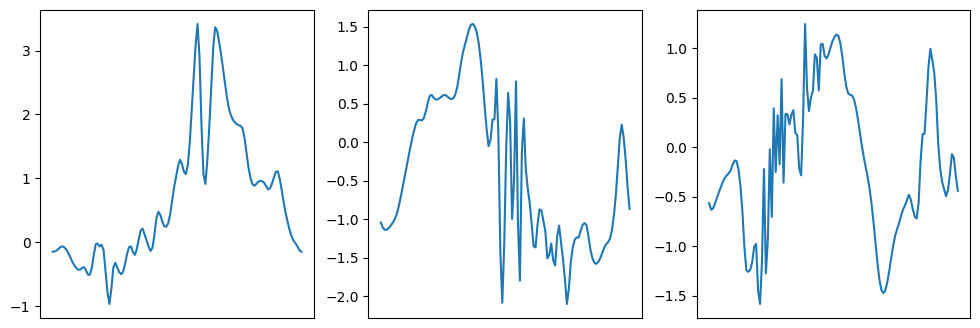

In [8]:
plot_time_series_row(x1, 3)

In [8]:
#load_data
config_load = 'turbulence_example_condi_64_J_6_Q_3_sigma_1'
x_k_condi = load_results( root, config_load)[0].to(device)[:1000]

std =W.decompose(x1)[1].std()
x_k_condi = x_k_condi*std

print(x_k_condi.shape)

torch.Size([1000, 1, 64])


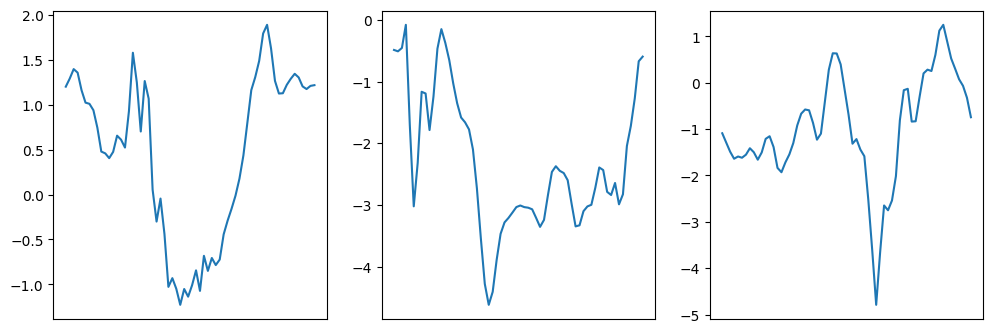

In [9]:
plot_time_series_row(x_k_condi, 3)

### Choose the model

In [10]:
n1, channels, M = x1.shape
print(f'(B, C, T) = ({n1}, {channels}, {M}).')

J = 6
Q = 3

# choose terms in the model
terms = ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real','Scalar_psi_quantile_confine','L_2','L_4','L_6','L_8']
#Filters
filters = return_Filters(M, J, 1, device=device)
filters_Q = return_Filters(M, J, Q, device=device)

(B, C, T) = (1000, 1, 128).


In [11]:
potentials = get_1d_potentials_condi(W,terms, J, filters,Q=Q,filters_Q=filters_Q, parallel=False)

## Solve the SDE

In [12]:
# SDE parameters
interpolant = 'Cos'
nt          = 50000
t           = 1-(1-torch.linspace(0, 1, nt + 1))**2
sigma       = 1

nb_workers      = x1.shape[0] # number of particles
nb_interpolants = x1.shape[0] # number of I_t (not necessarily the dataset size, since several noise paths could be considered per data sample)

batch_size = x1.shape[0]#//2

regularization = 1e-1

Solver = SDE_condi(W,x1, nb_workers, nb_interpolants, t, sigma, potentials, batch_size, device=device, regularization=regularization, interpolant=interpolant
                   ,x_k_condi =x_k_condi)

Signal detected as 1D: (B, C, T) = (1000, 1, 64).
The model has 238 potentials.


In [11]:
config = 'turbulence_1000_'+str(M)+'_J_'+str(J)+'_Q_'+str(Q)+'_sigma_'+str(sigma)

In [12]:
print(config)

turbulence_1000_128_J_6_Q_3_sigma_1


In [ ]:
xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

597it [01:29,  6.63it/s]

In [ ]:
save_results(xt, theta_t, dH_t_bound, t, root, config)

In [ ]:
# Check (non negligible) moments matching

threshold = 1e-8 # threshold above which should be considered

plot_moment_matching(barphi_e, barphi_p, t, threshold)

In [13]:
xt, theta_t, dH_t_bound, t =load_results( root, config)

## Analyze the result

Looking at the samples and moment matching along the dynamics:

In [14]:
def plot_time_series_row(Data, N):
    random_indexes = np.arange(N)

    fig, axs = plt.subplots(1, N, figsize=(4*N, 4))
    for i in range(N):
        idx = random_indexes[i]
        axs[i].get_xaxis().set_visible(False)
        axs[i].plot(Data[idx,0].cpu())
    plt.show()

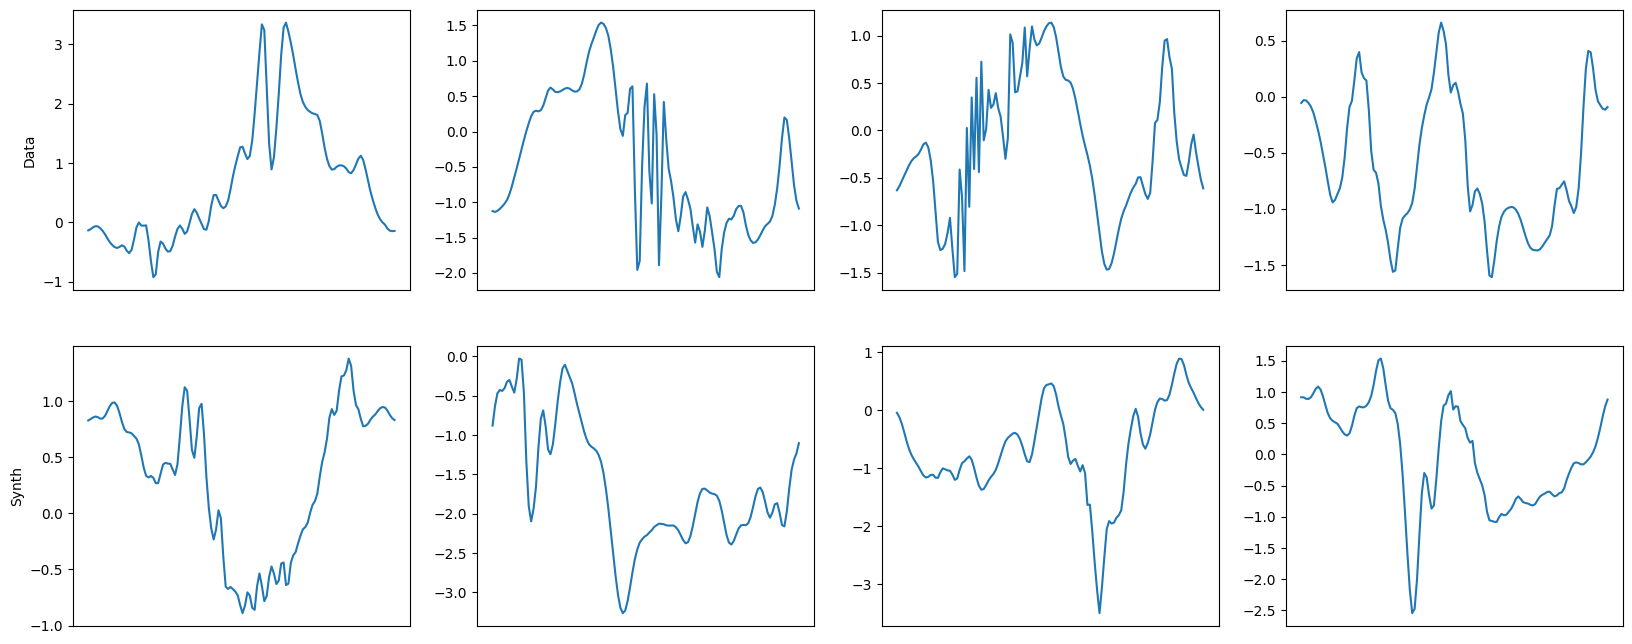

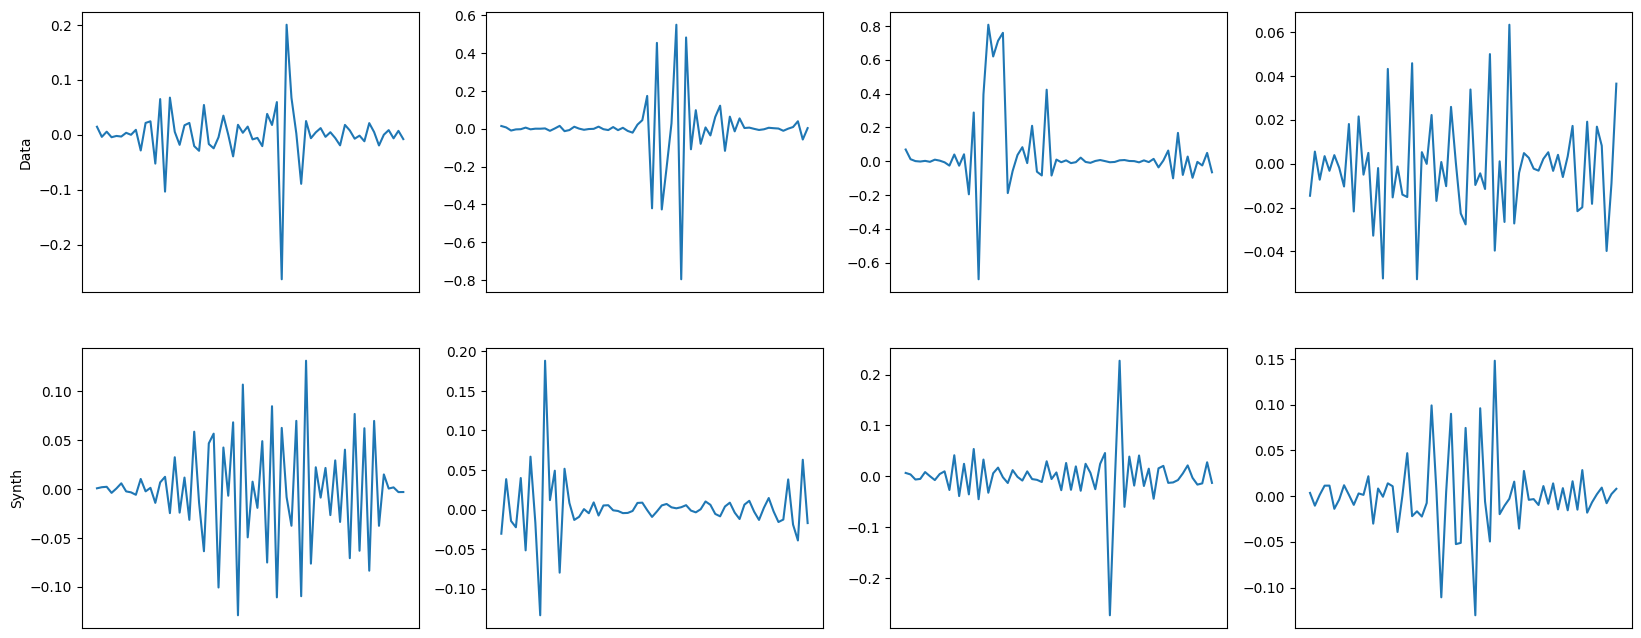

In [15]:
# Visual Check
Compare_time_series_row(x1,xt, 4)
# Visual High_freq
Compare_time_series_row(W.decompose(x1)[0],W.decompose(xt)[0], 4)

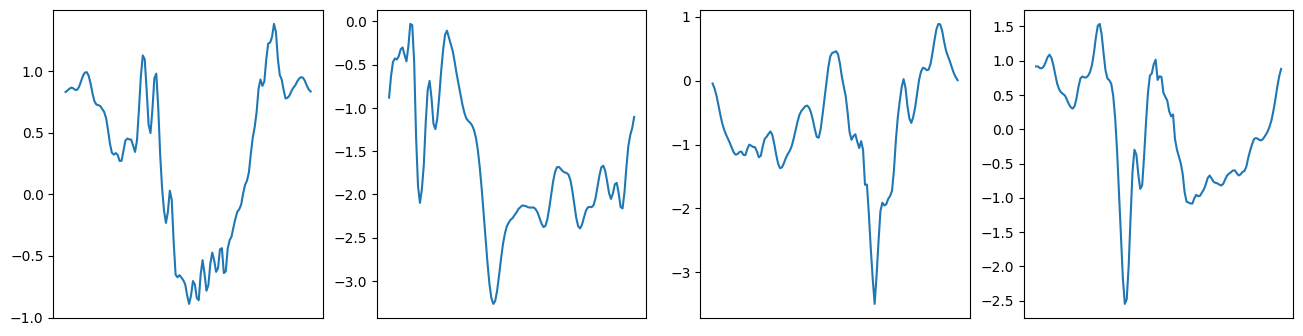

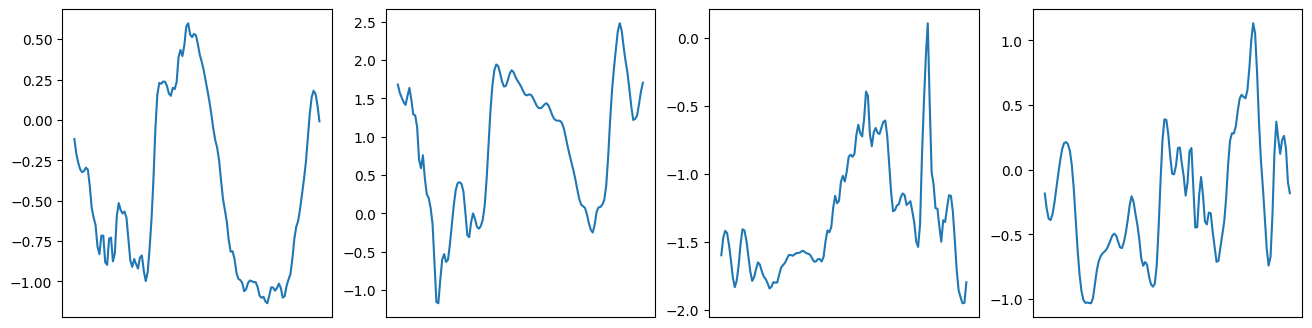

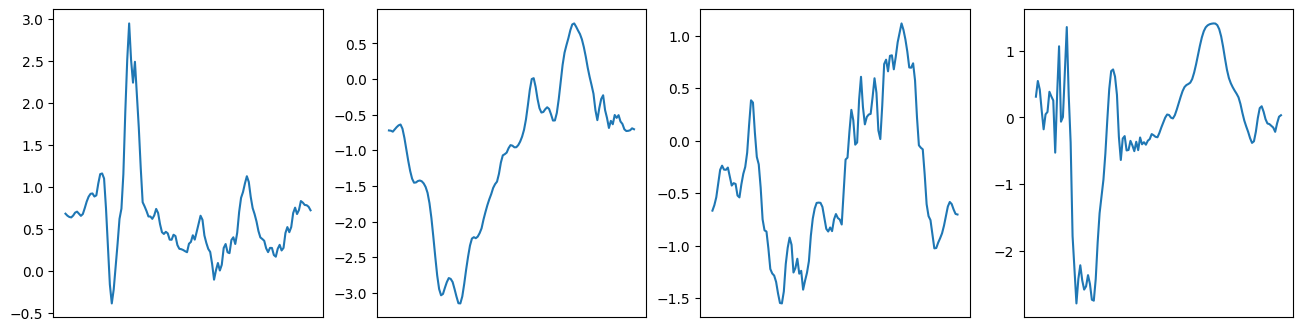

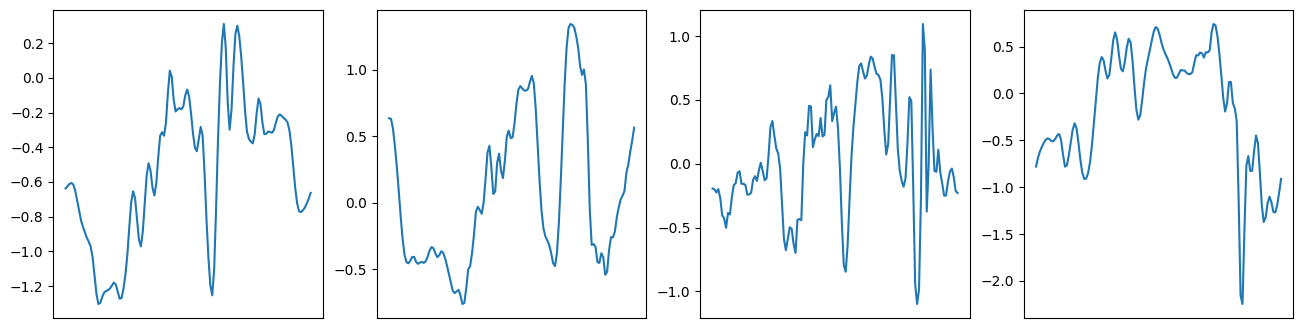

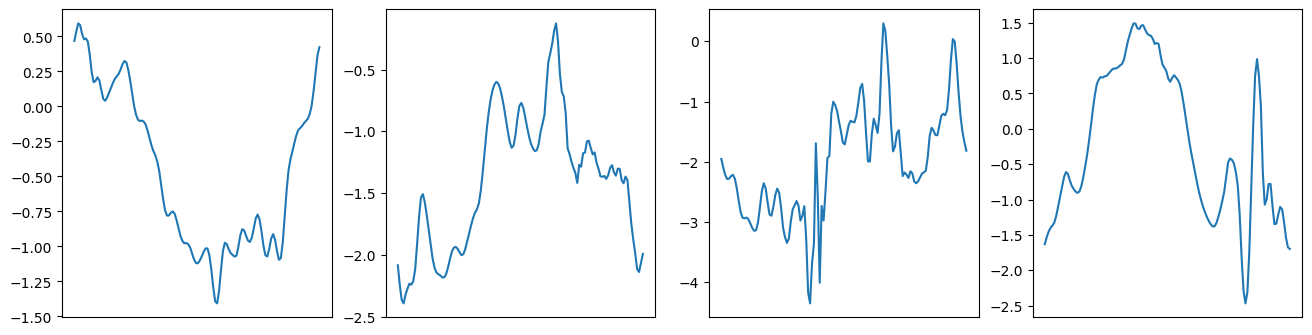

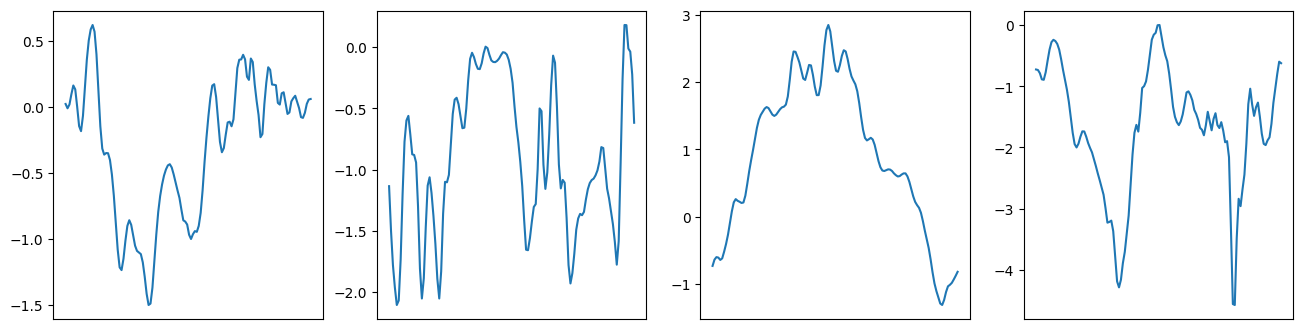

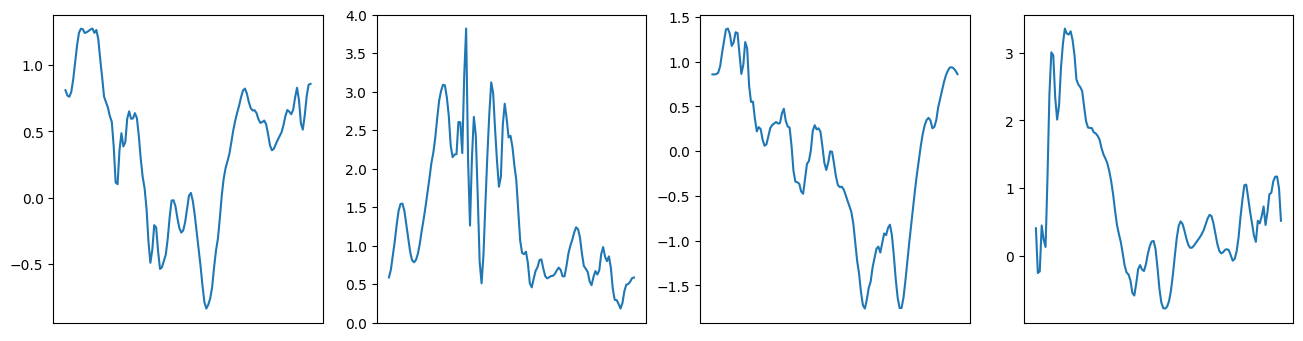

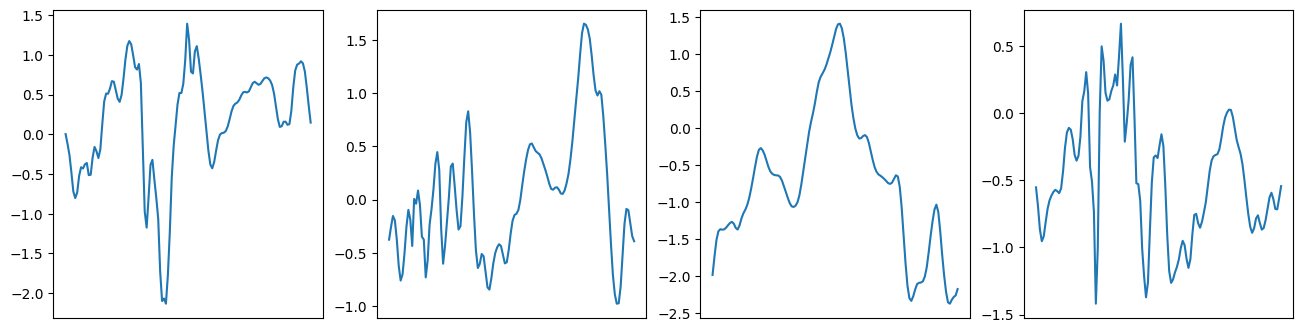

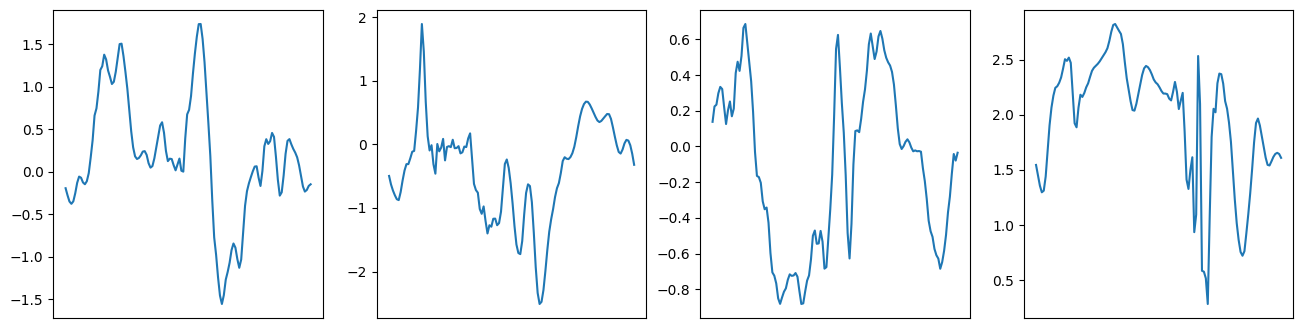

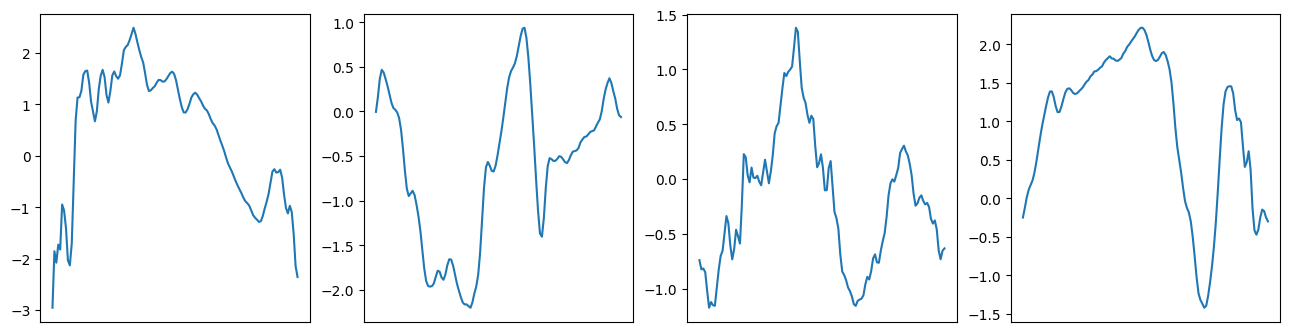

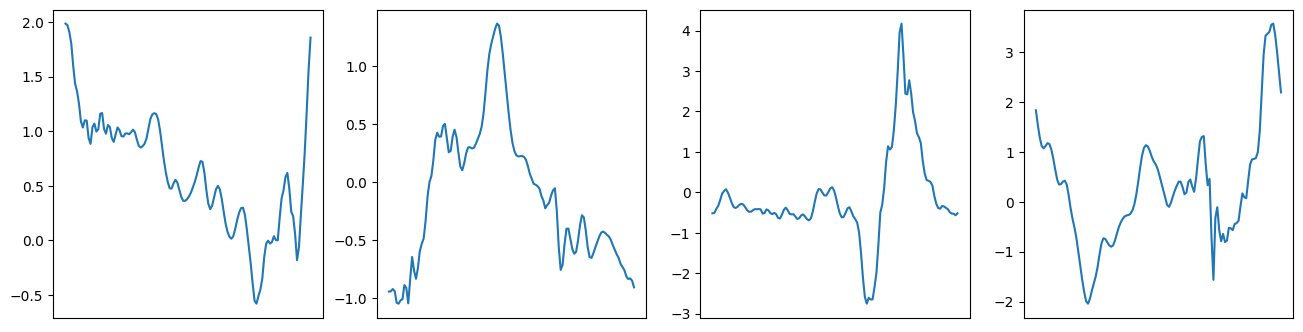

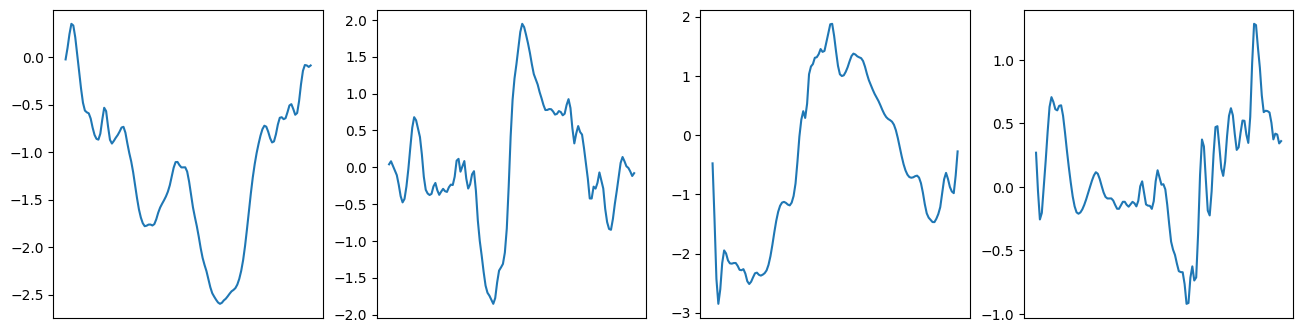

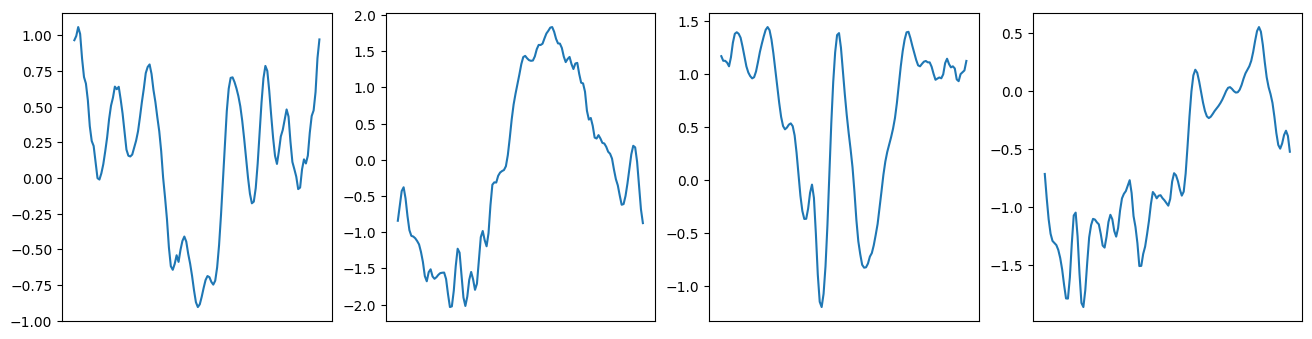

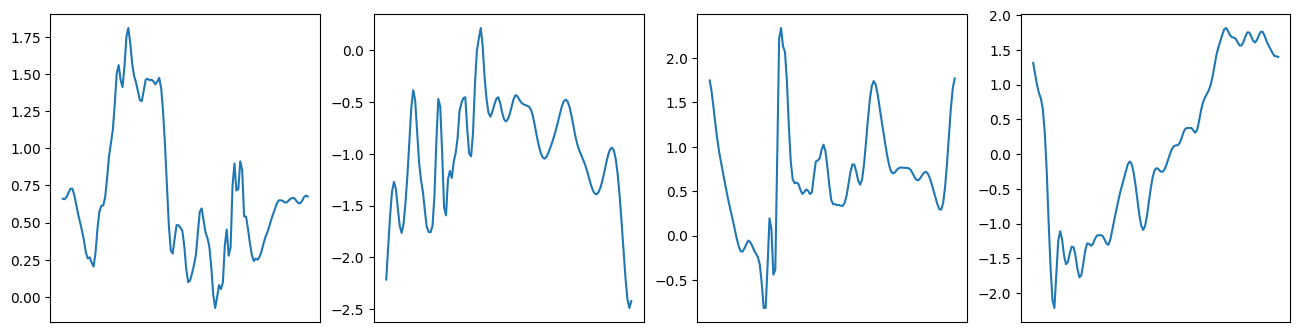

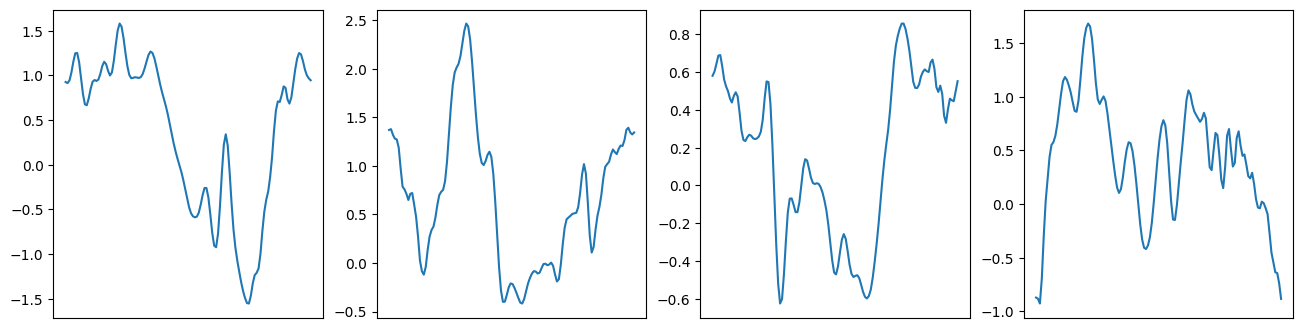

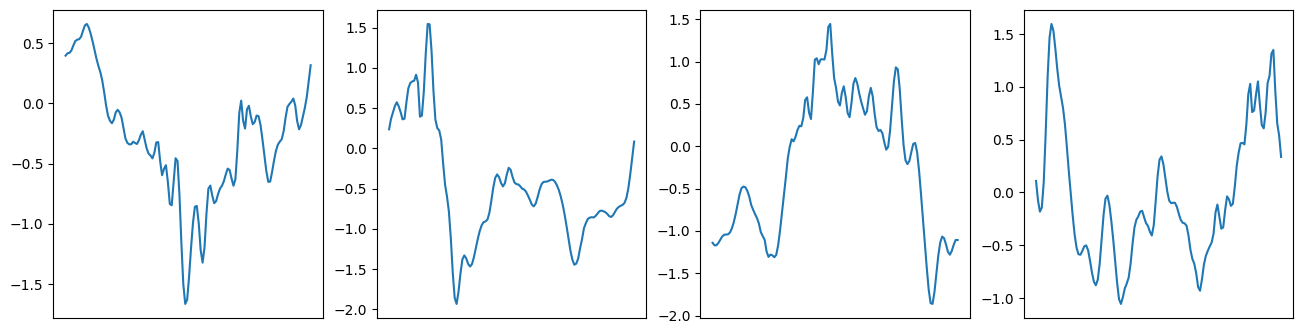

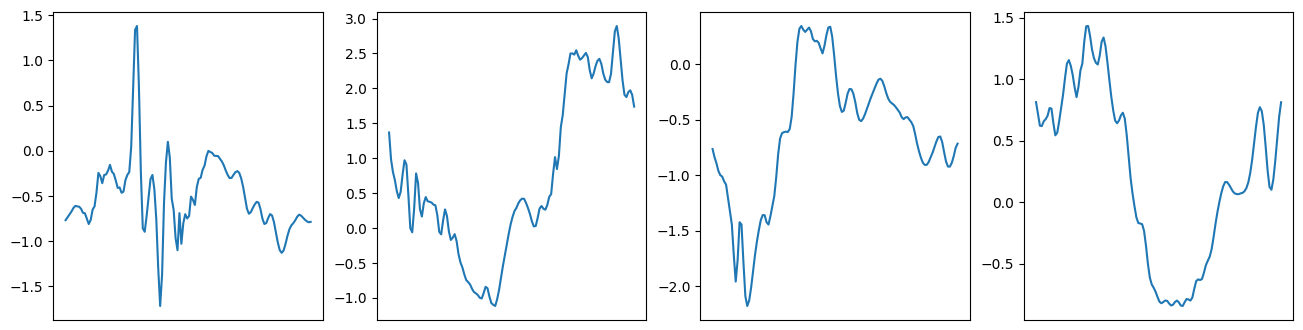

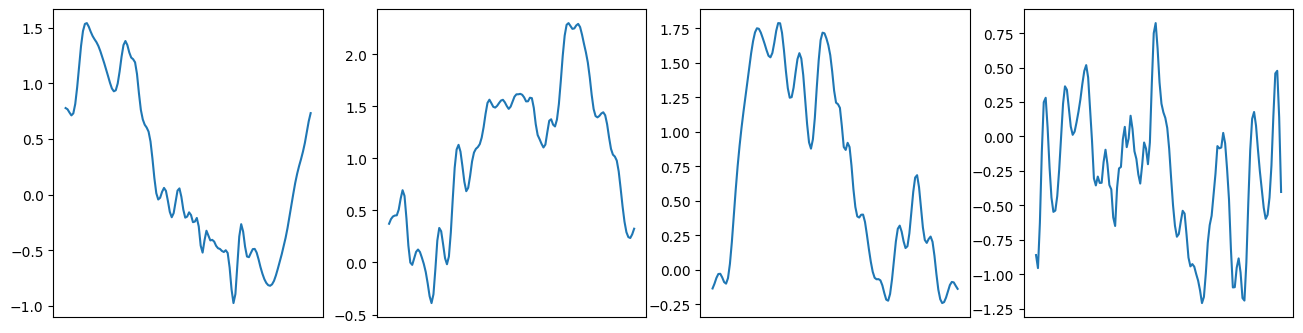

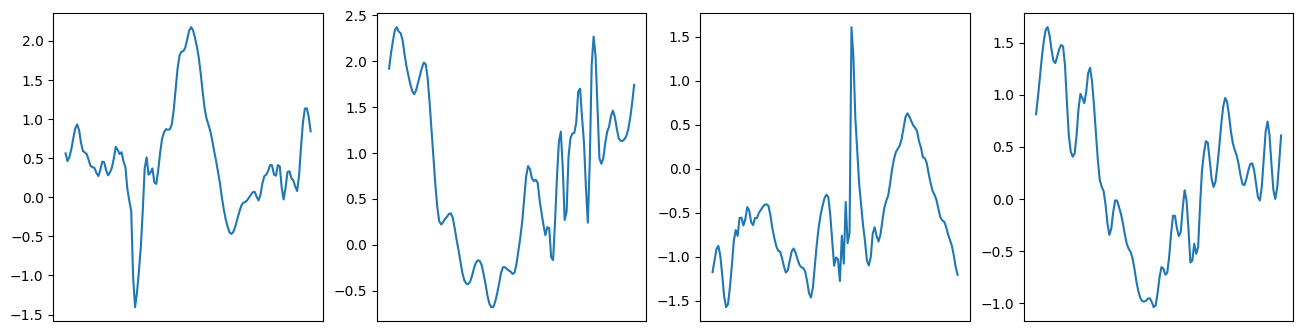

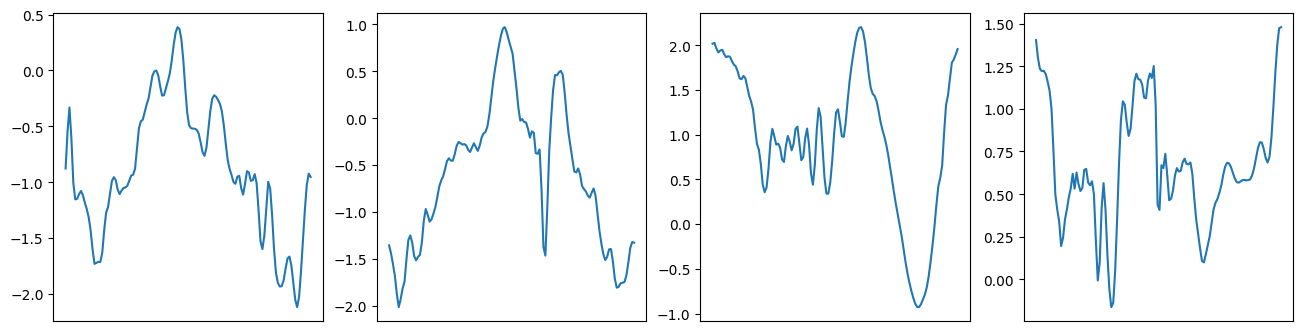

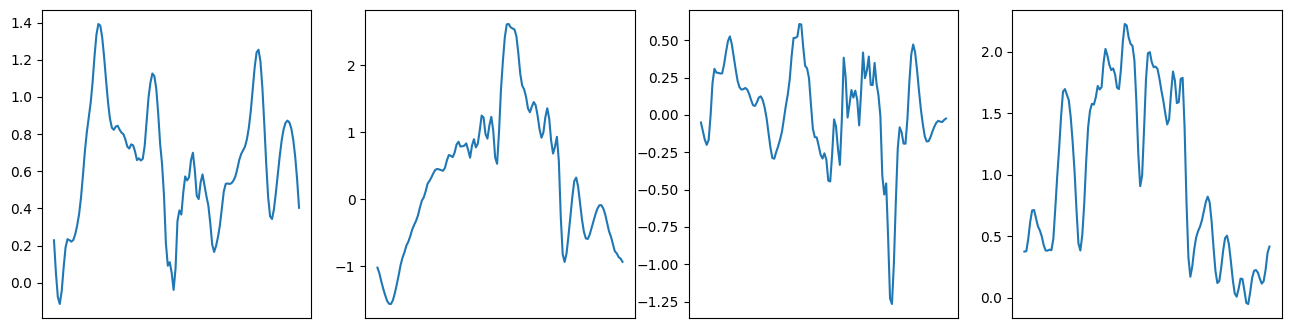

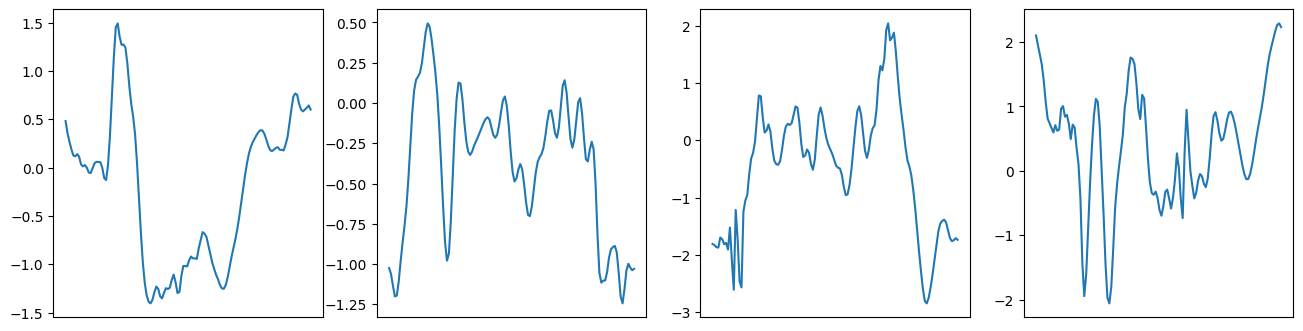

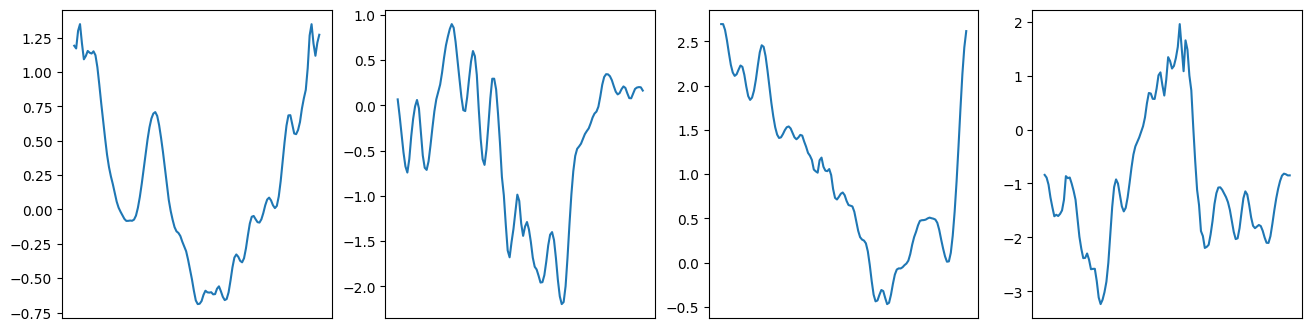

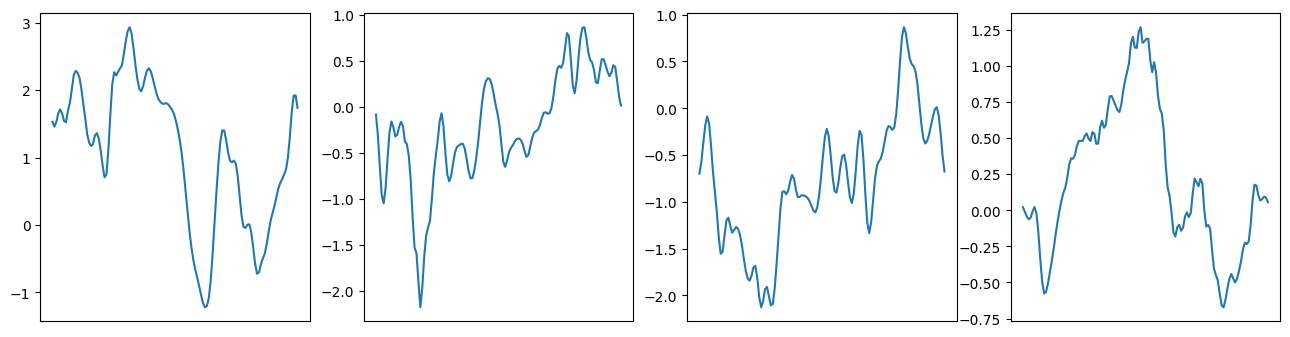

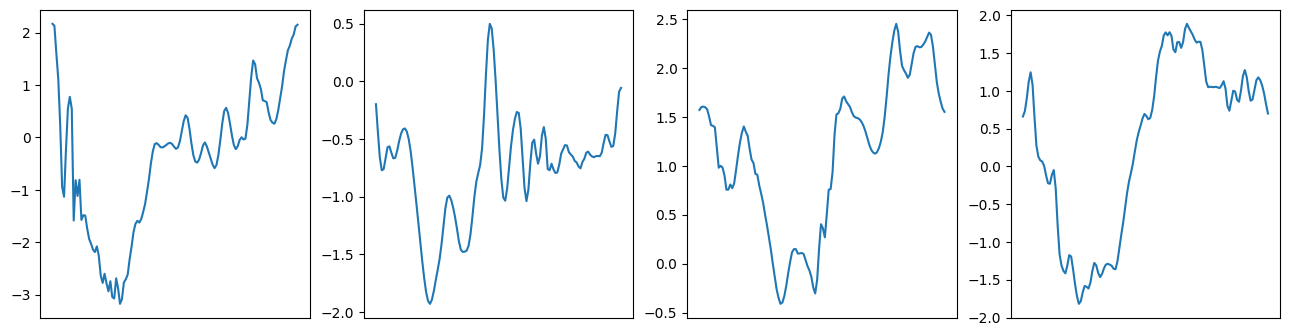

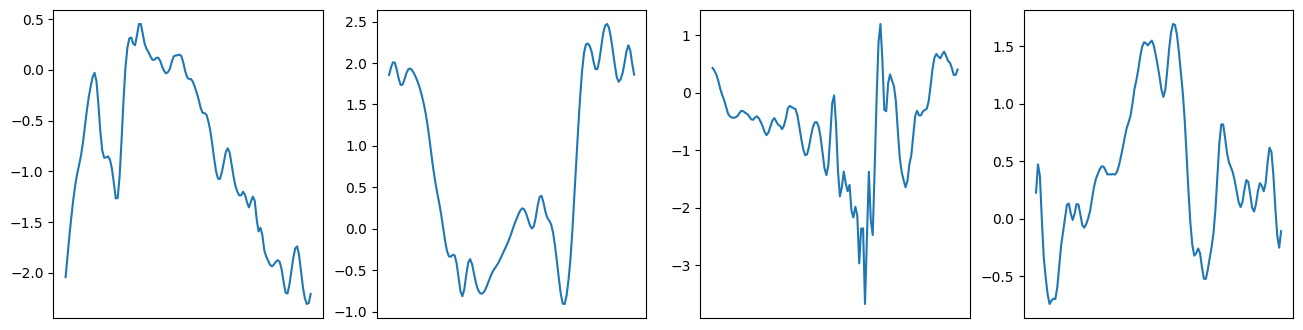

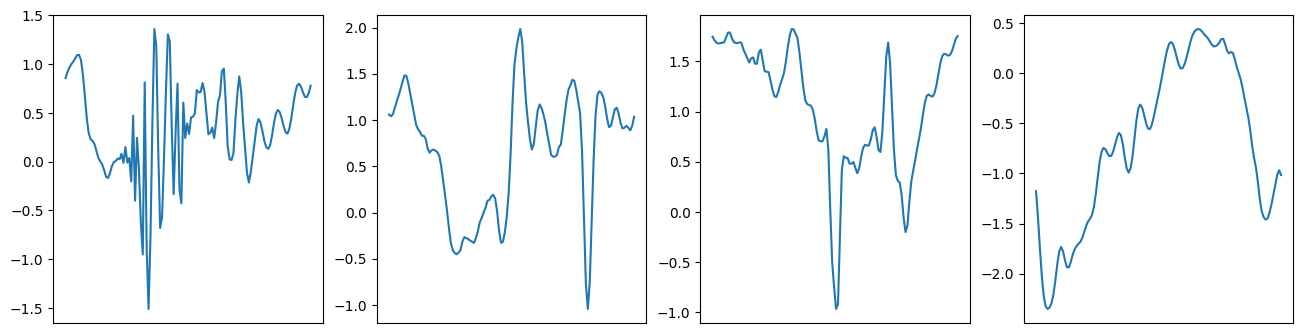

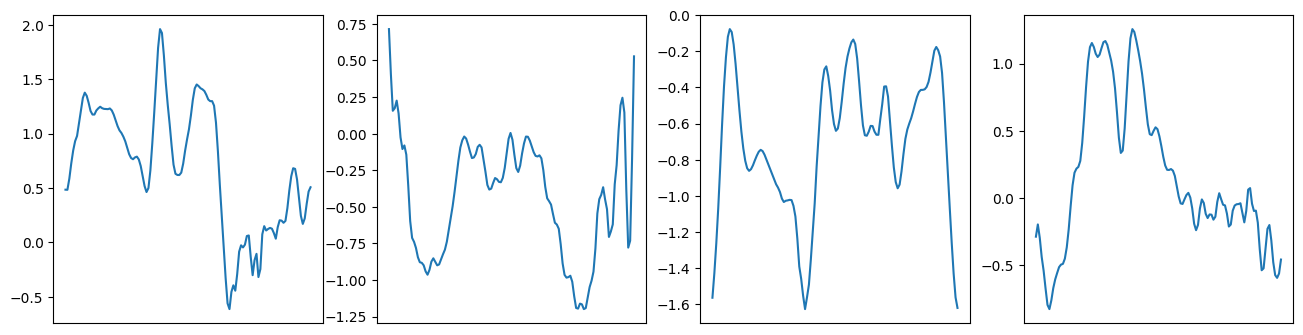

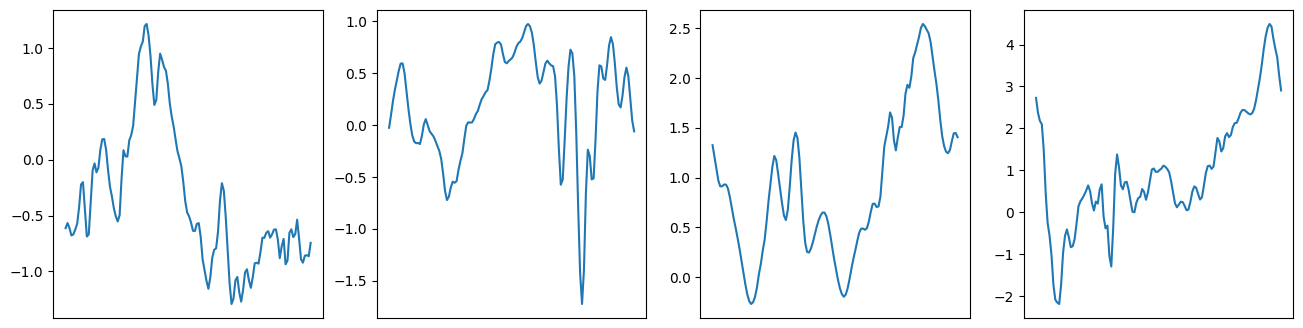

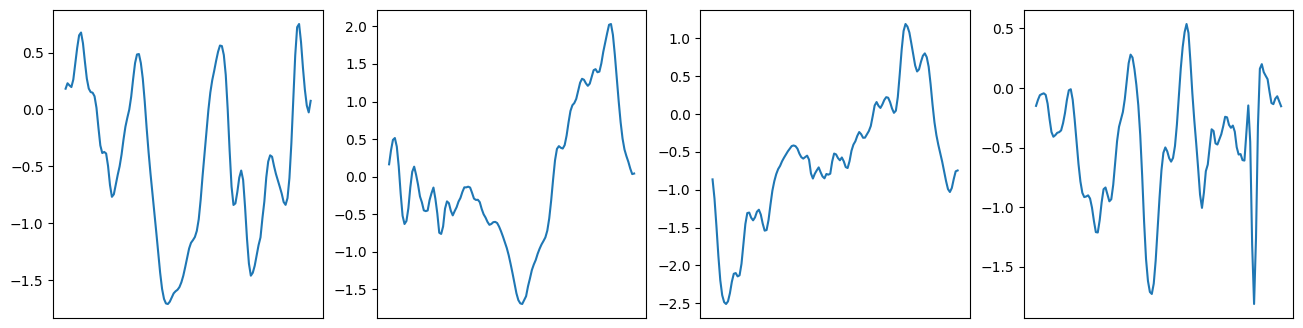

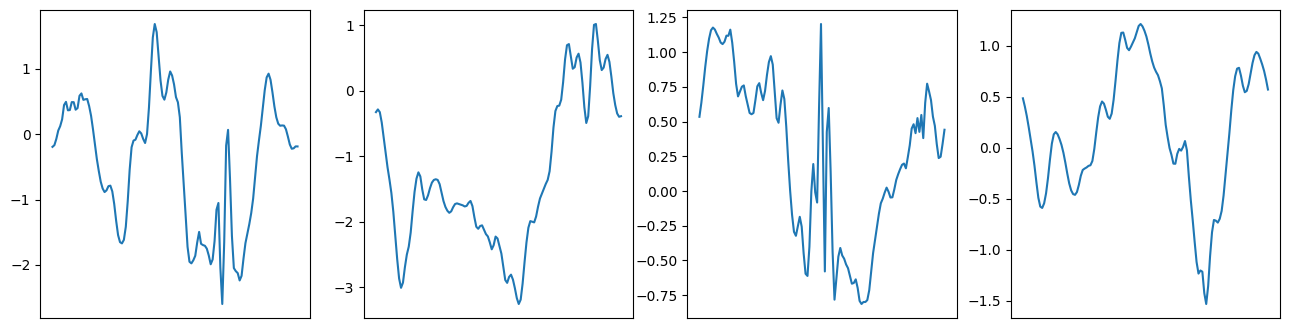

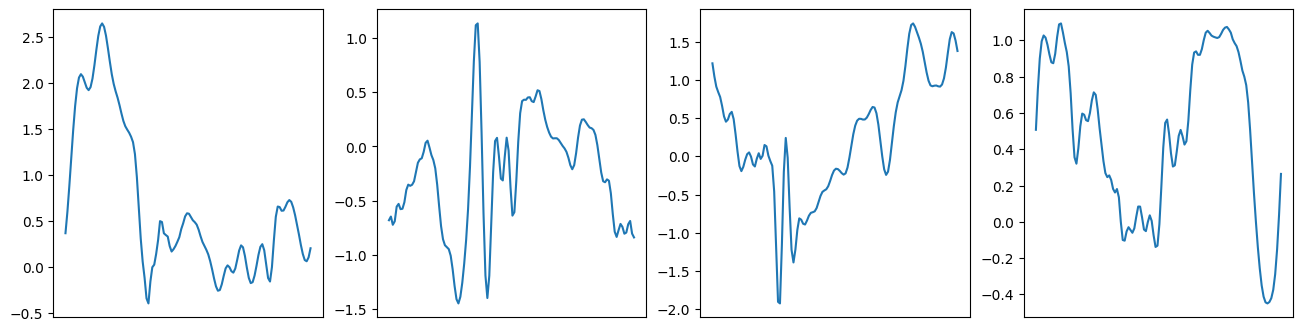

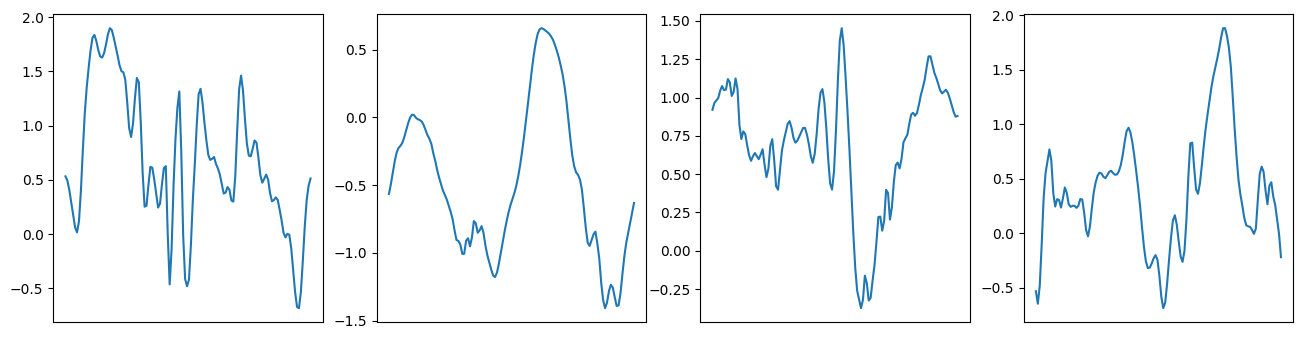

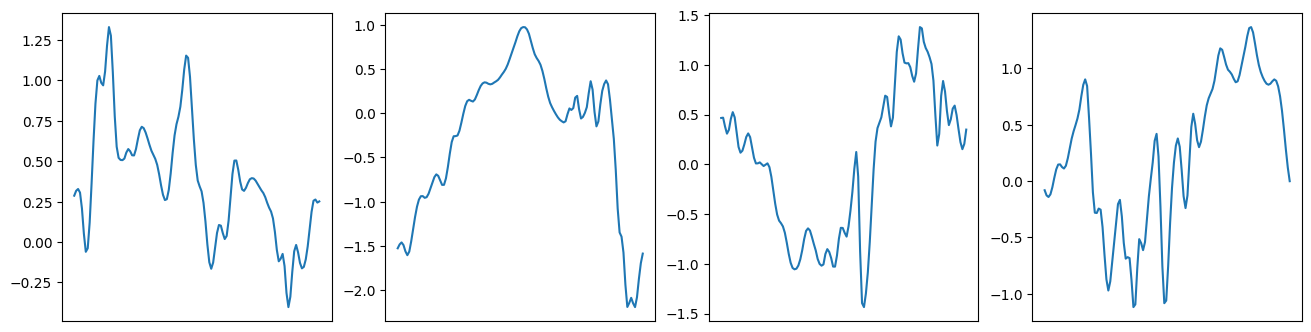

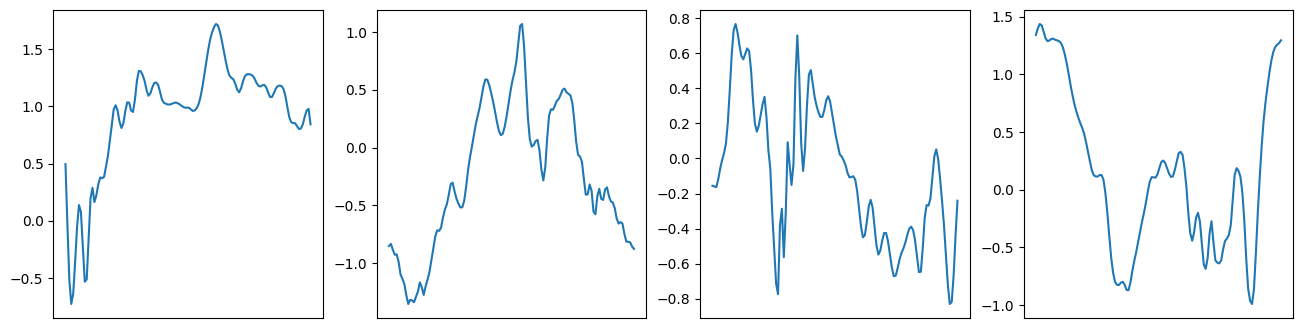

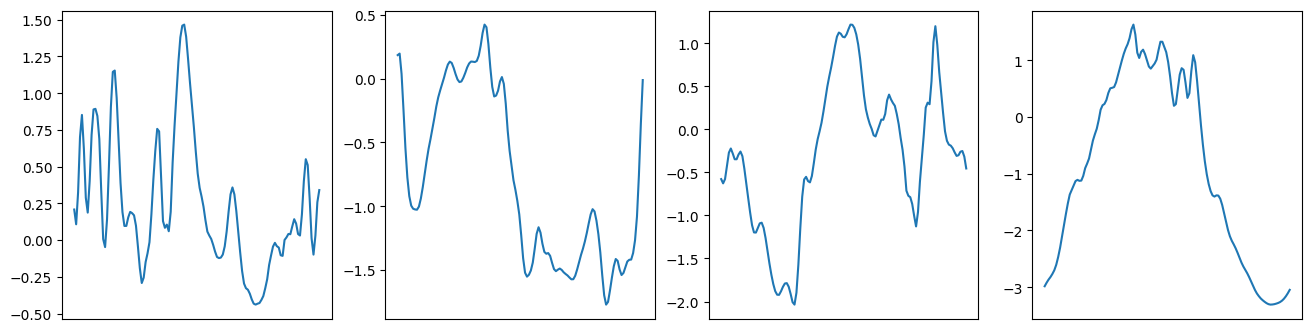

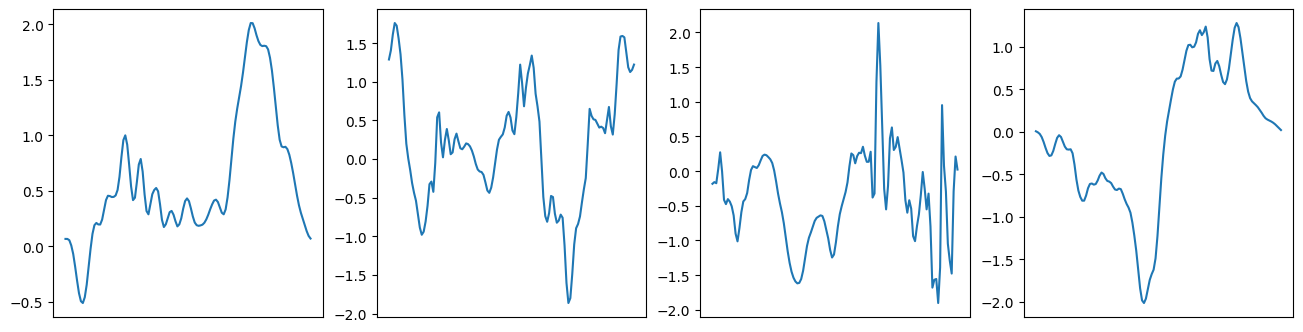

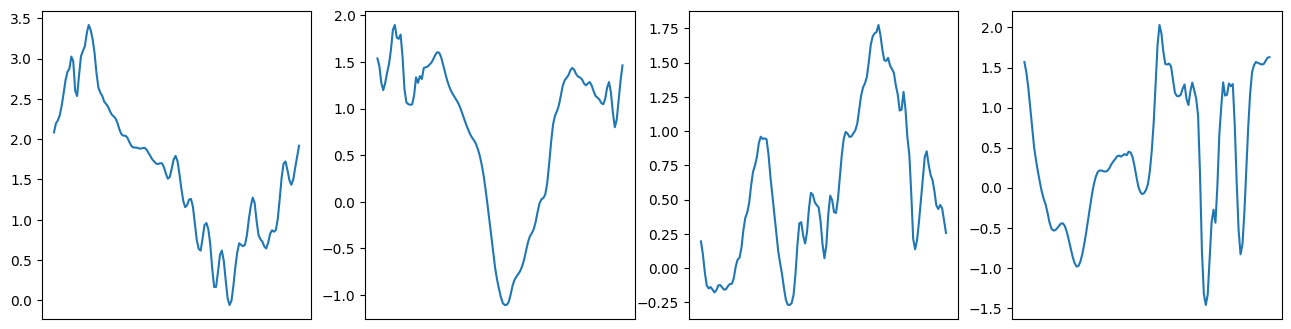

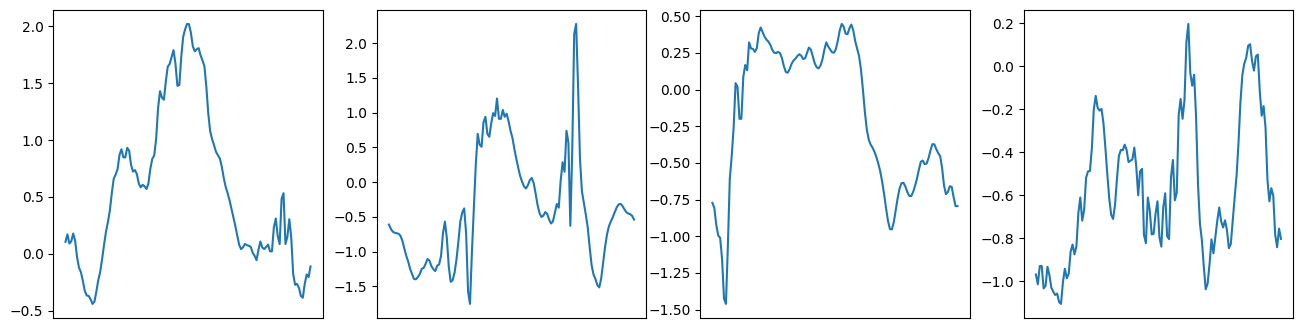

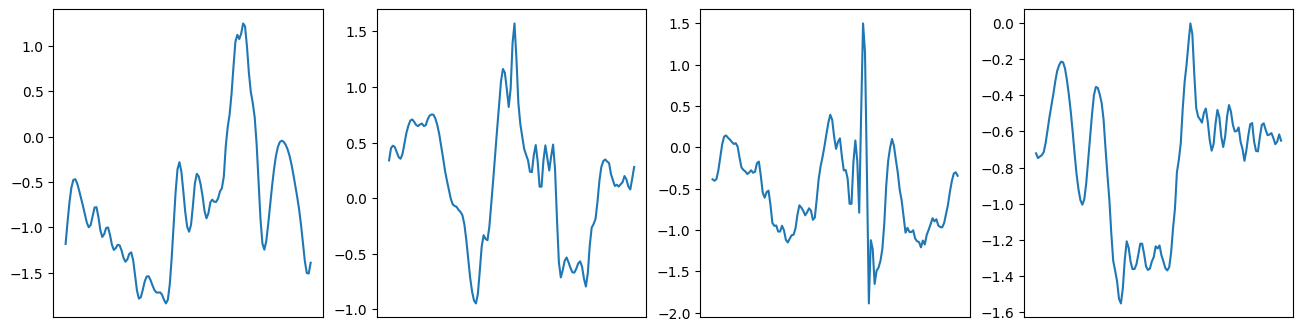

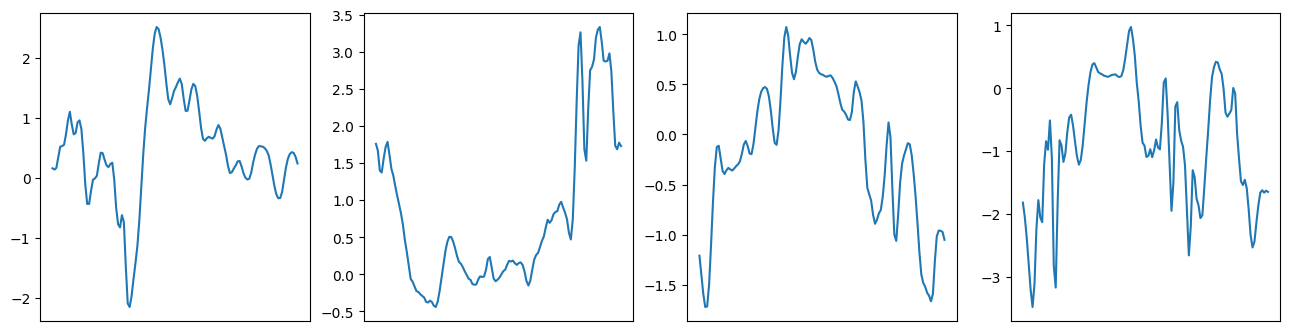

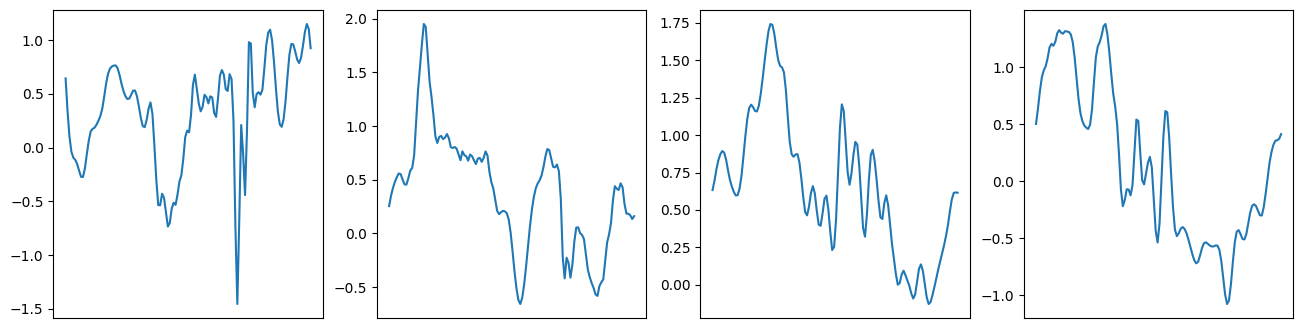

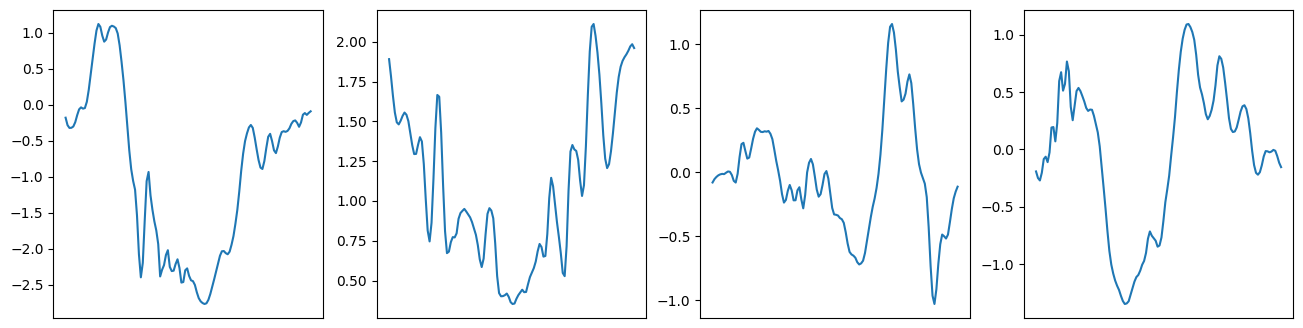

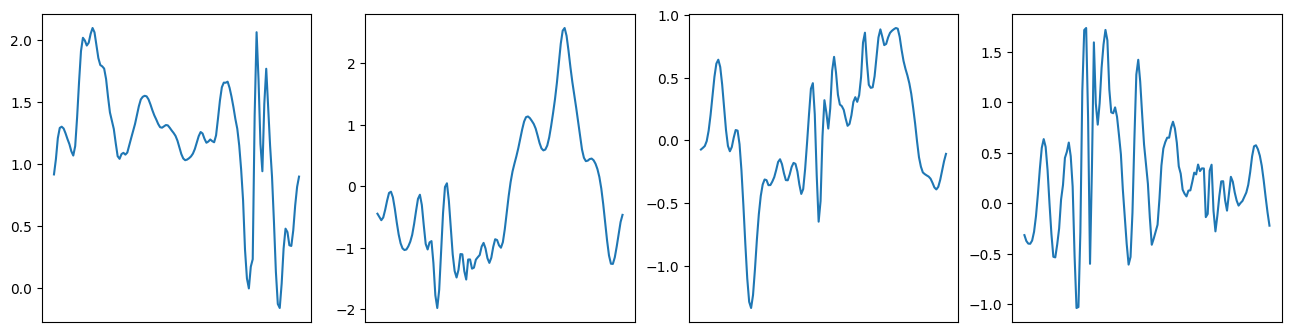

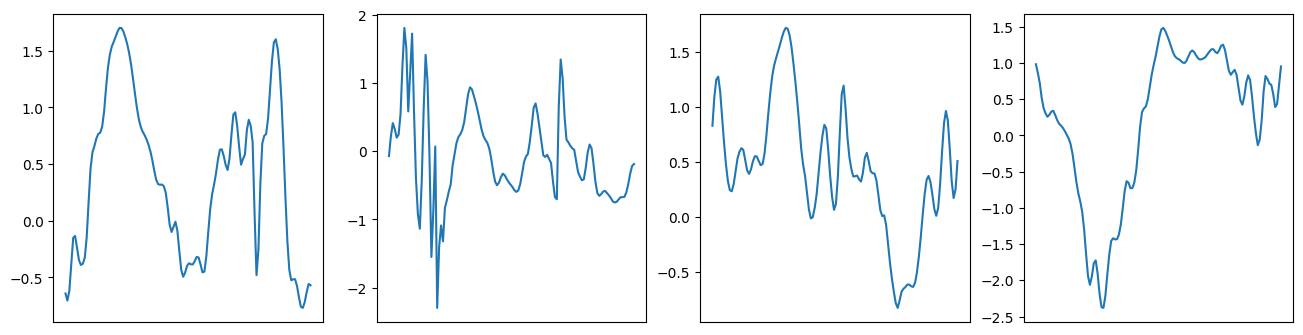

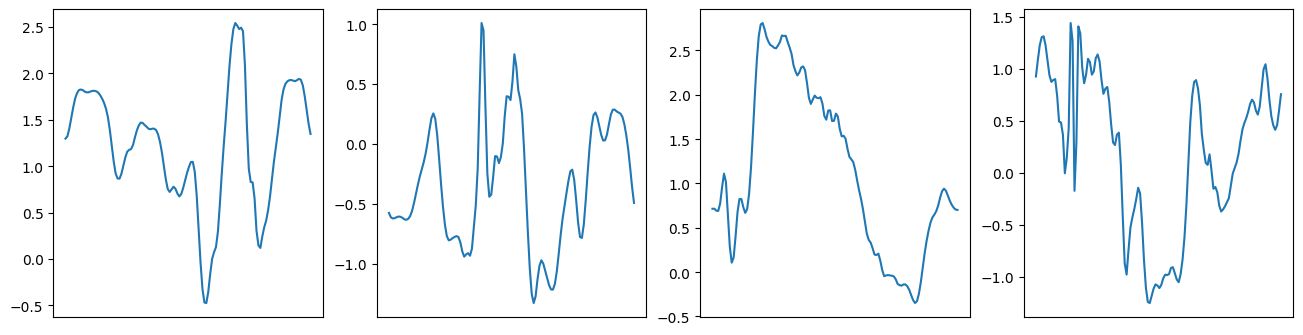

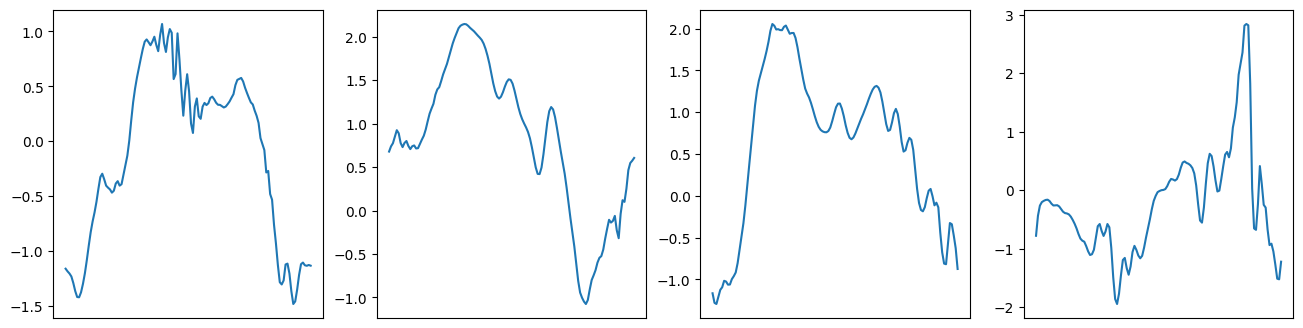

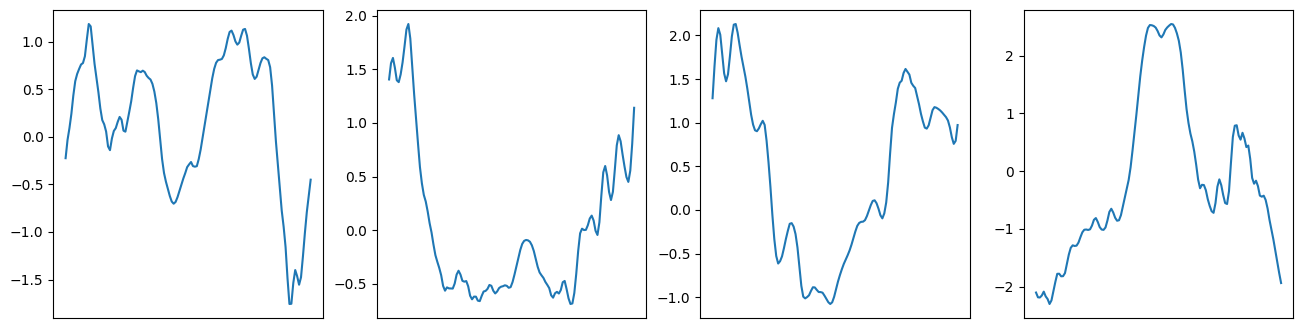

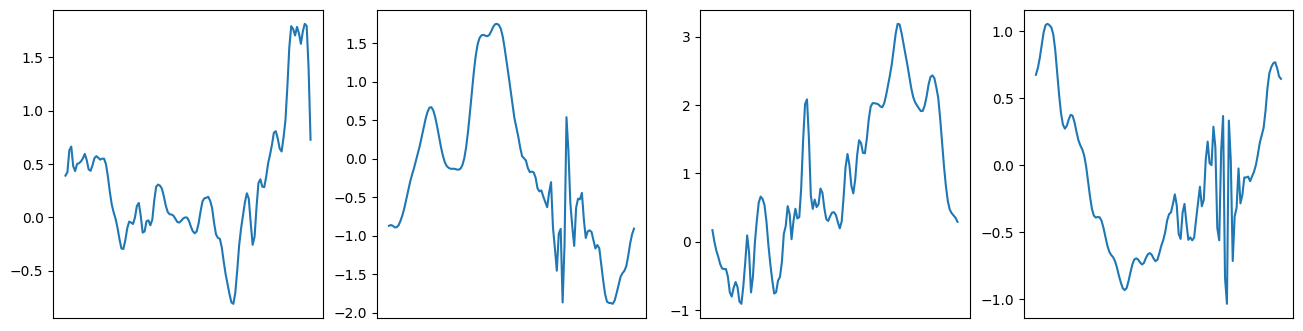

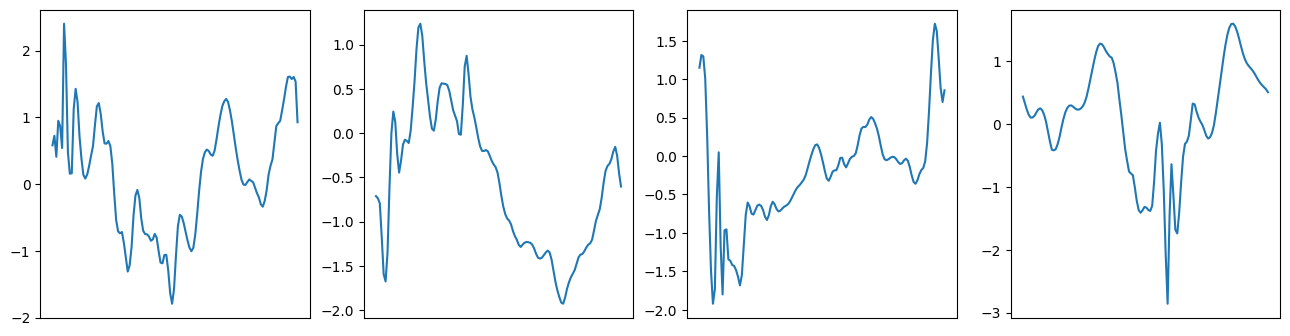

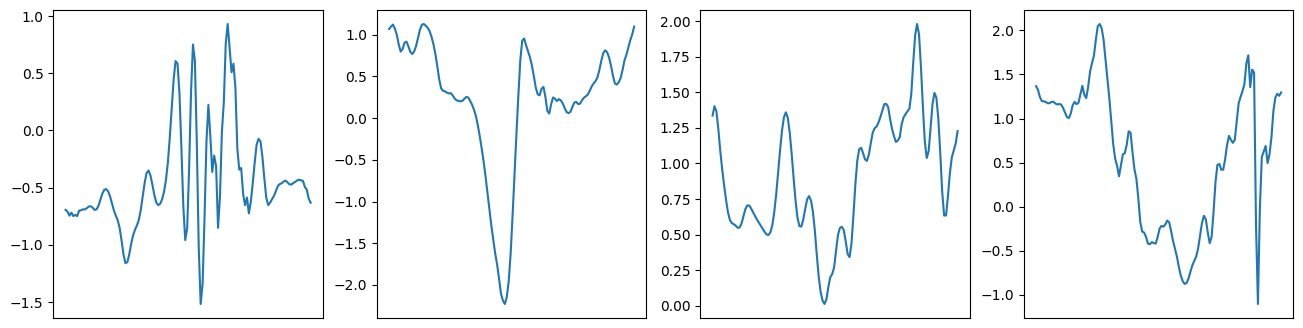

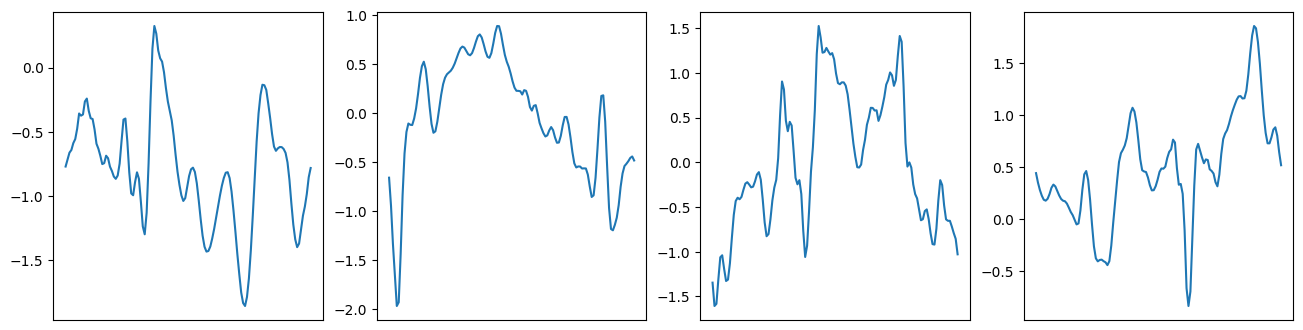

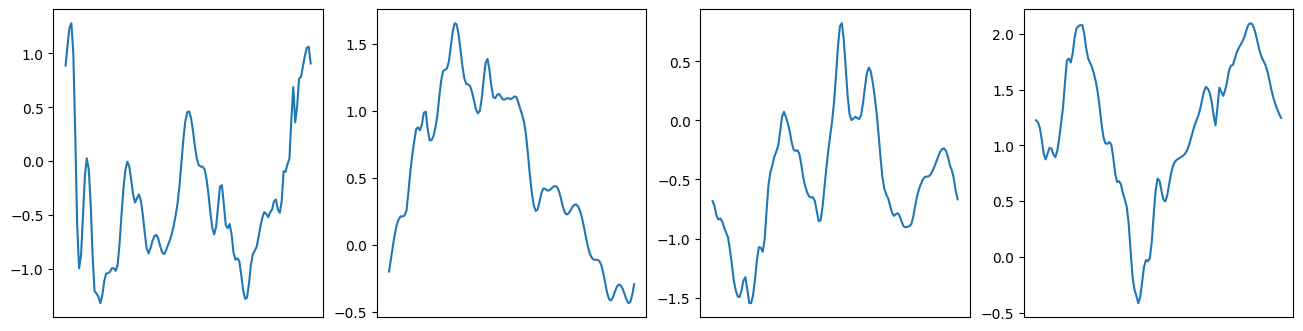

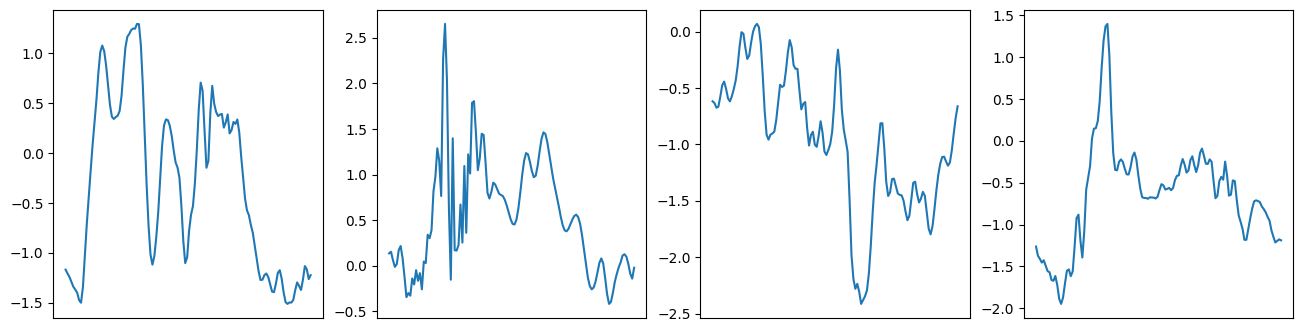

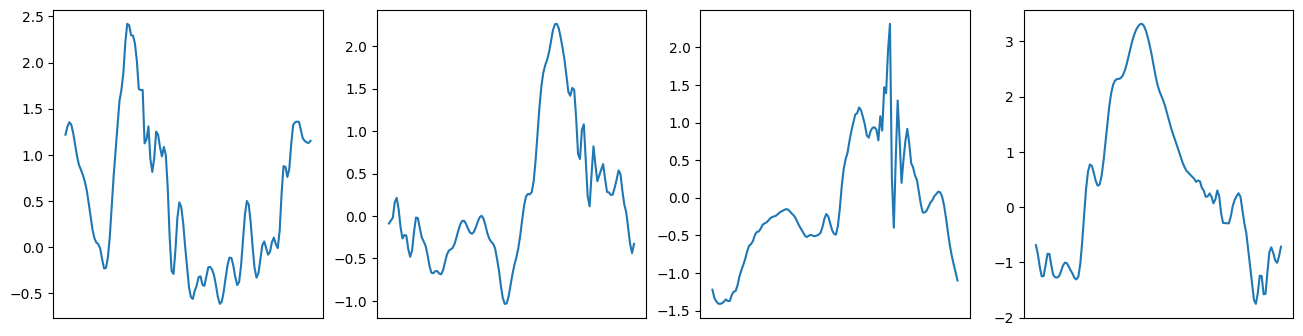

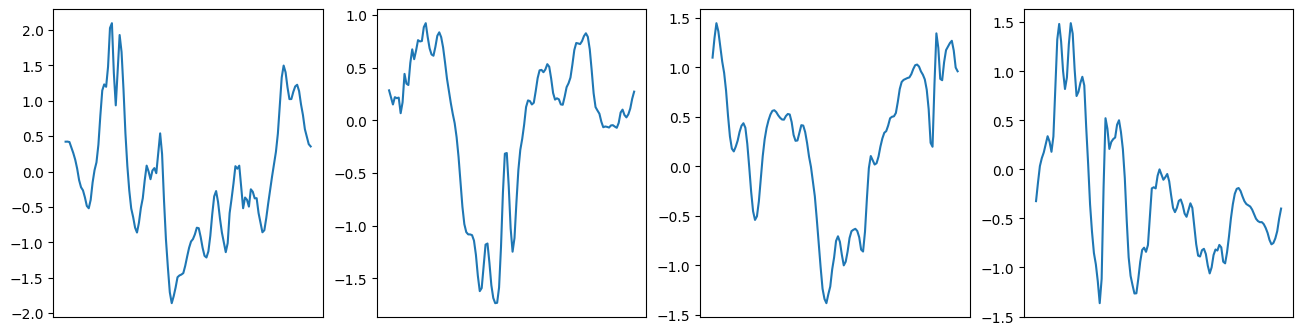

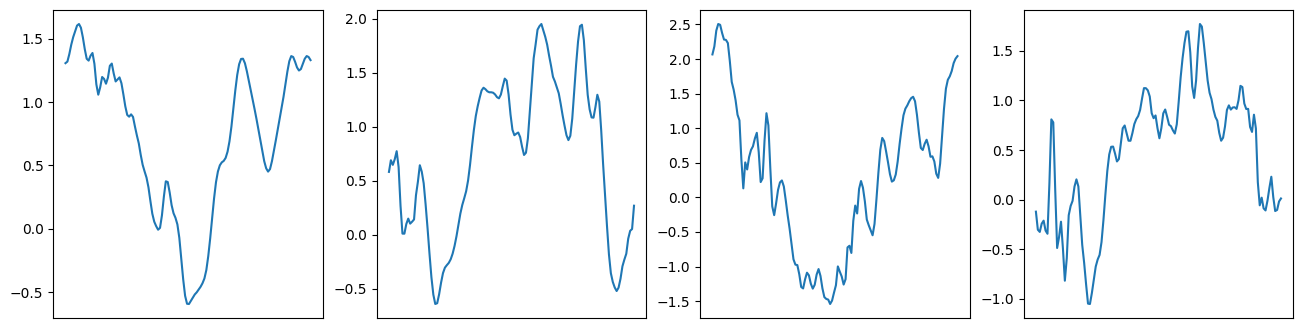

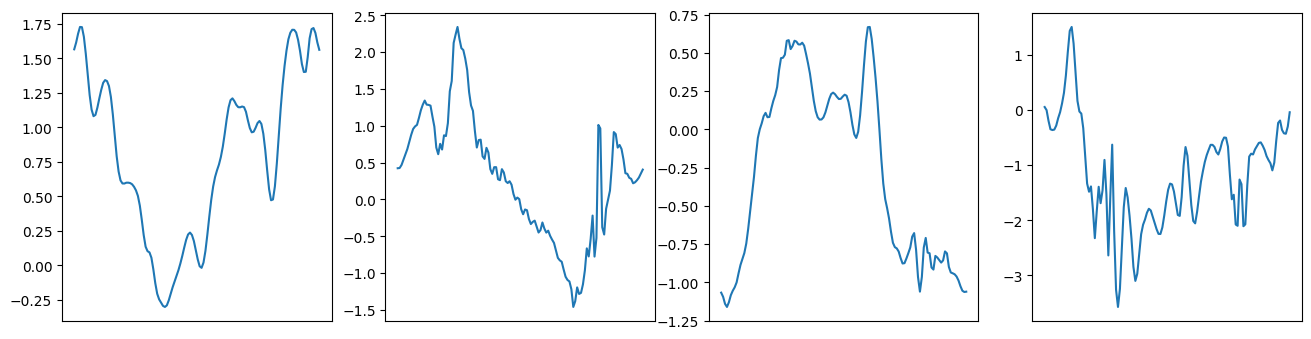

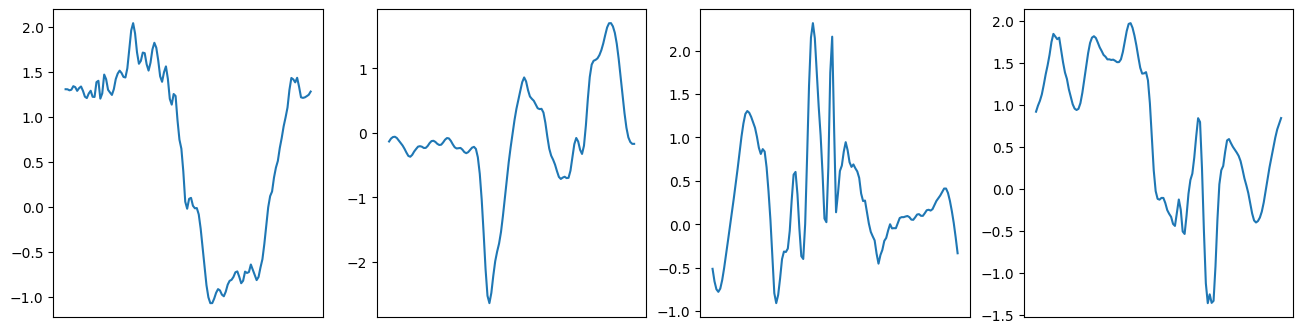

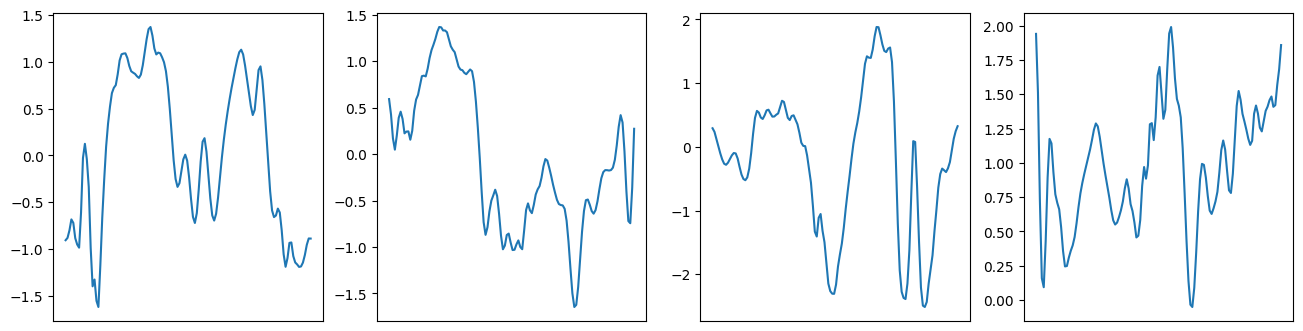

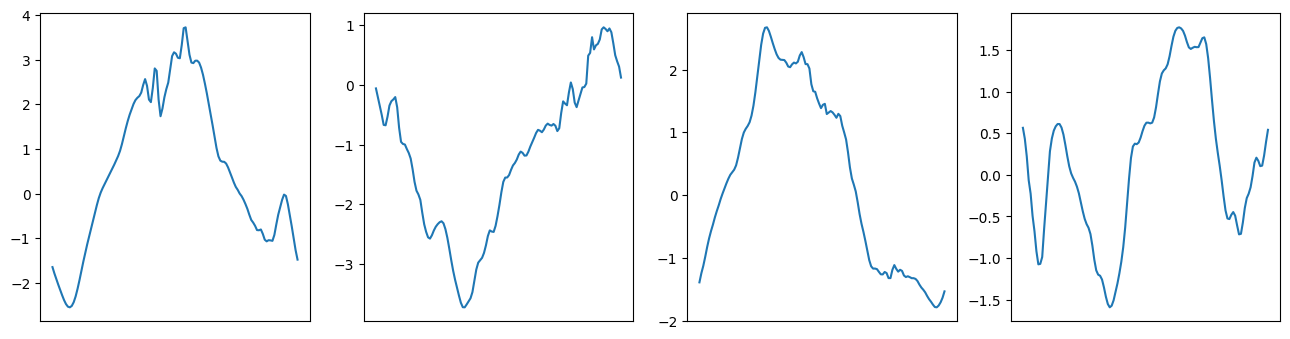

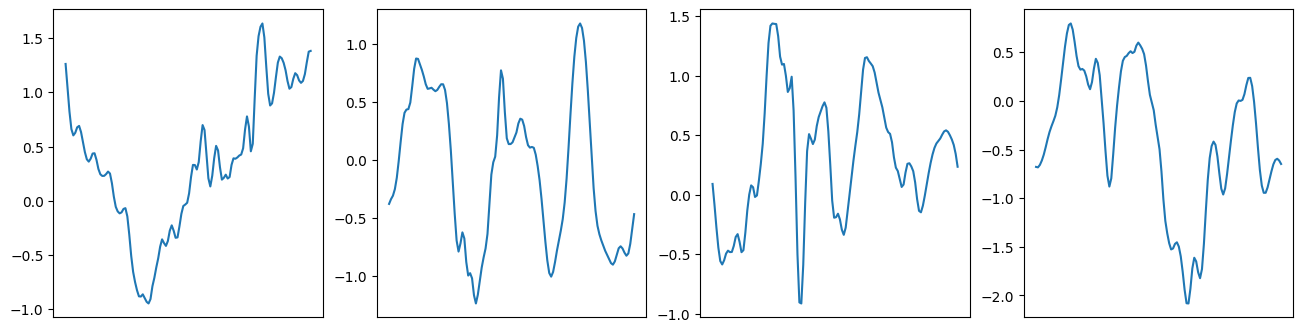

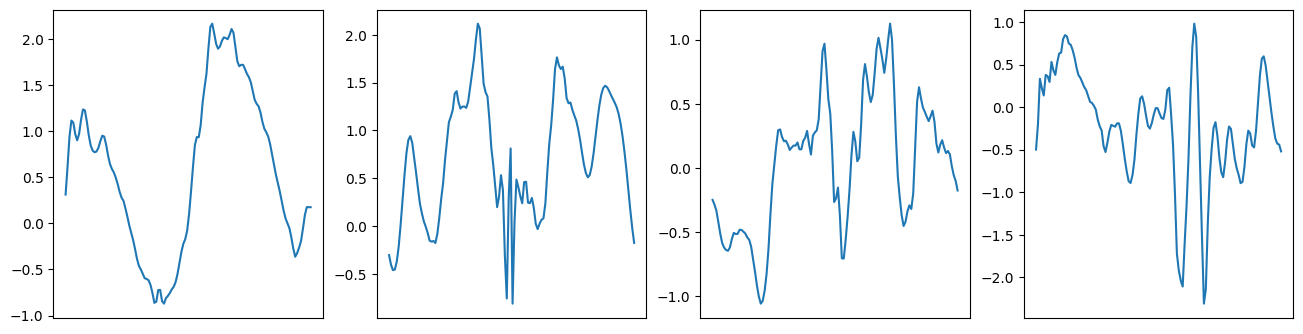

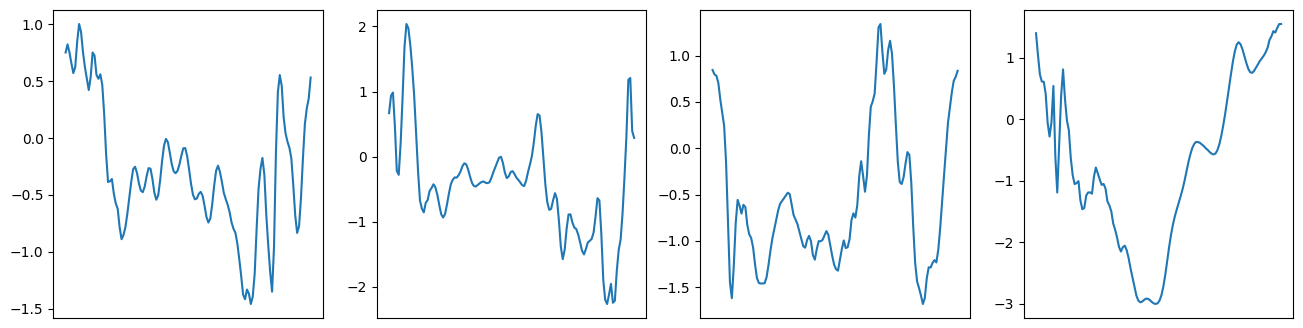

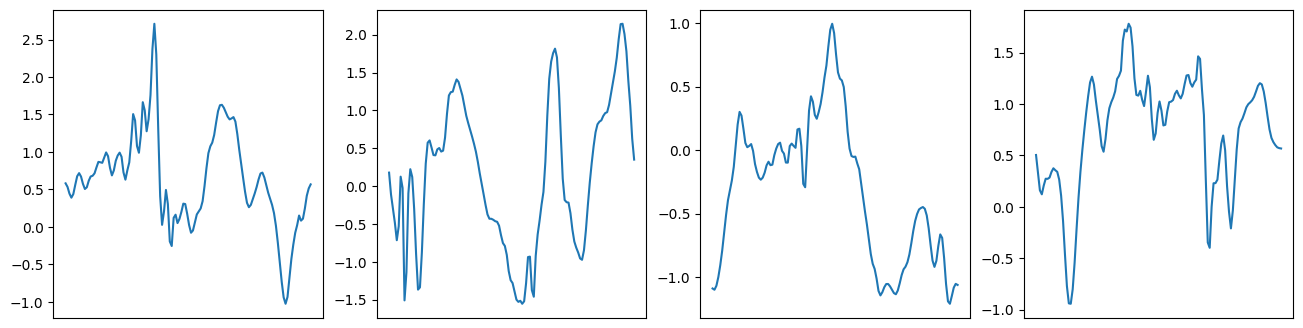

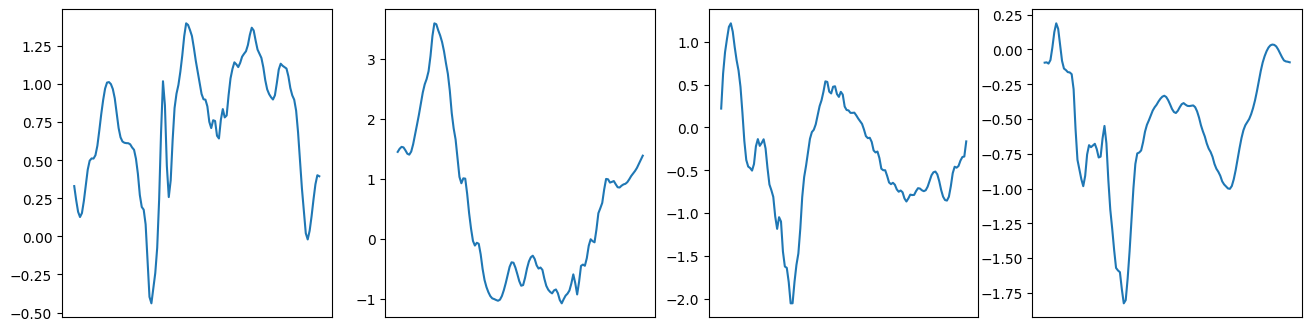

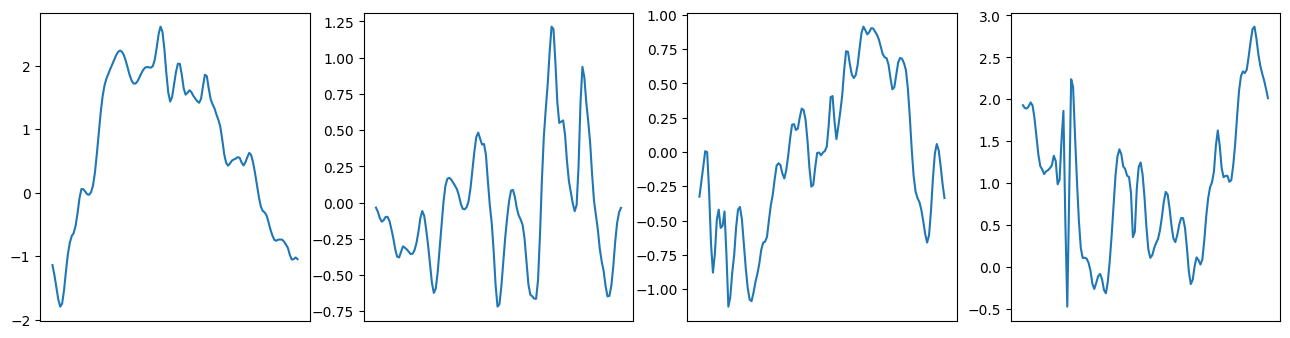

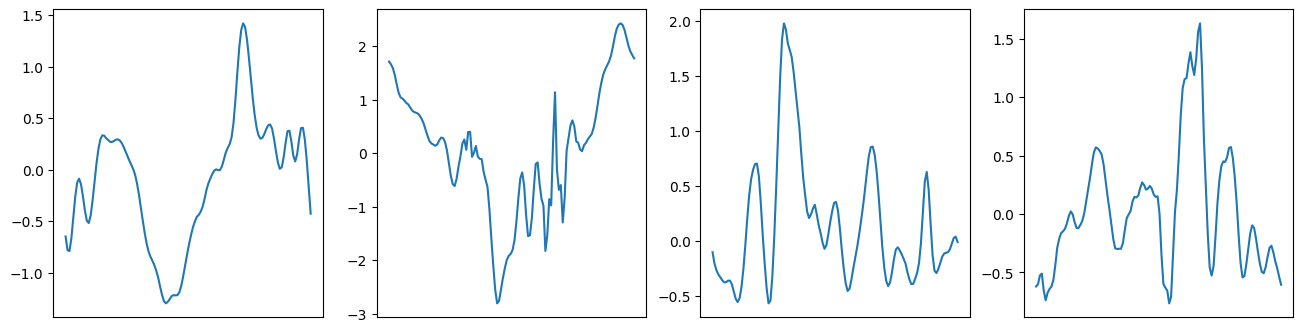

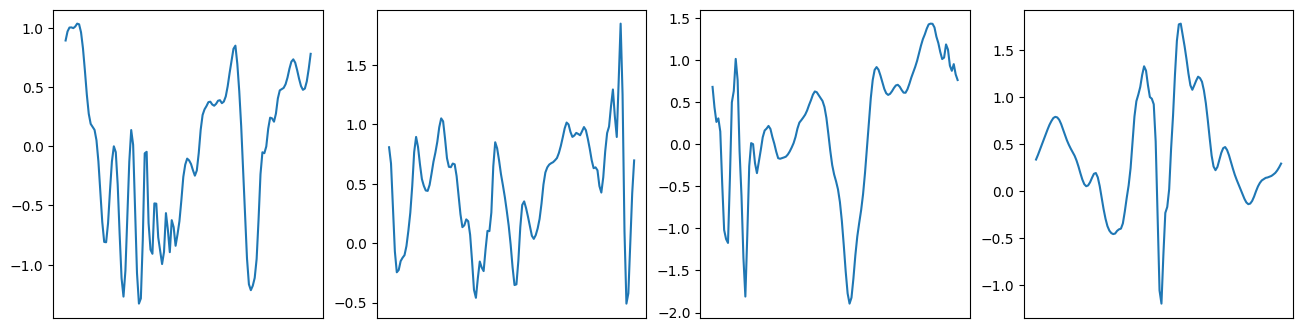

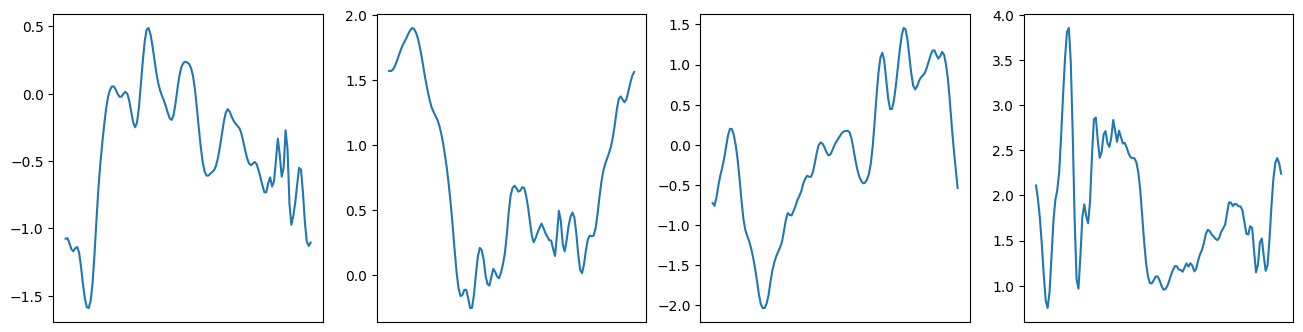

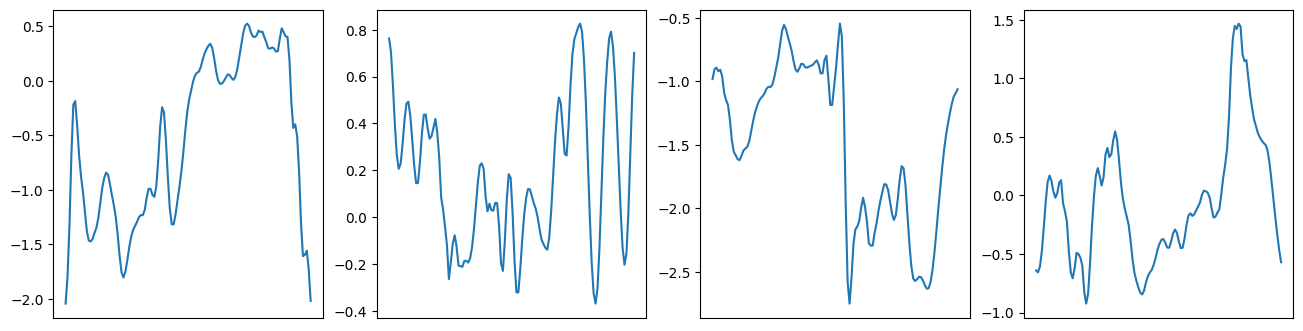

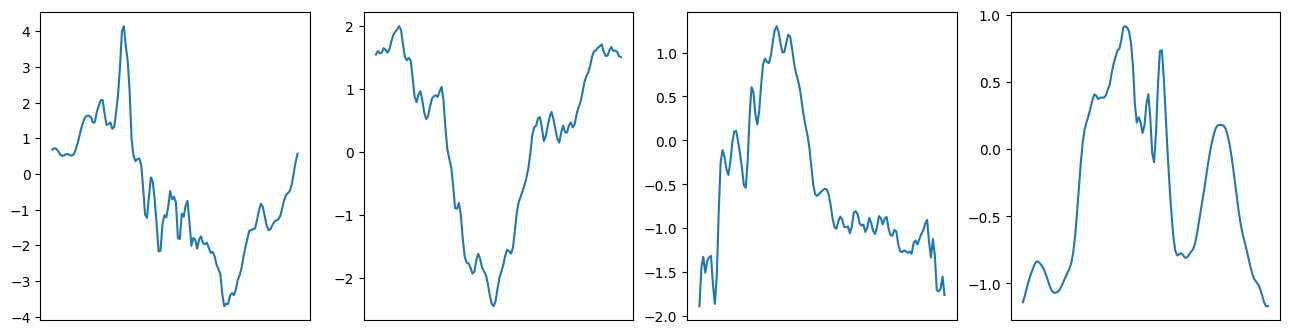

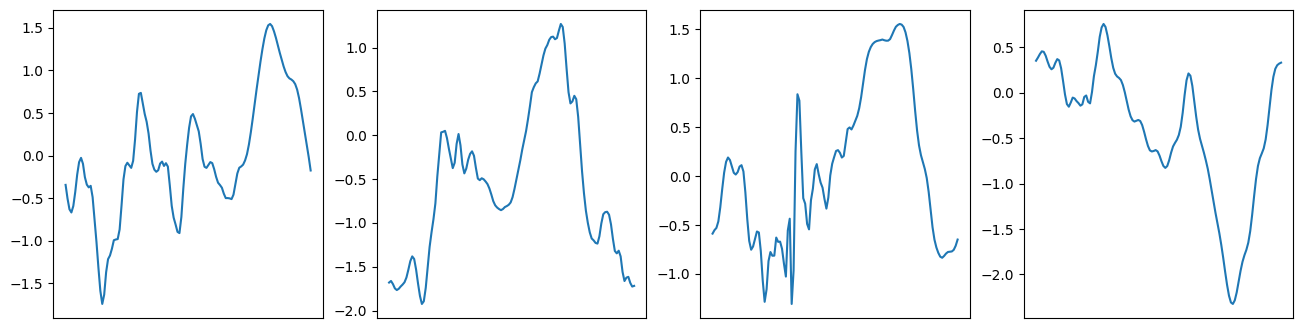

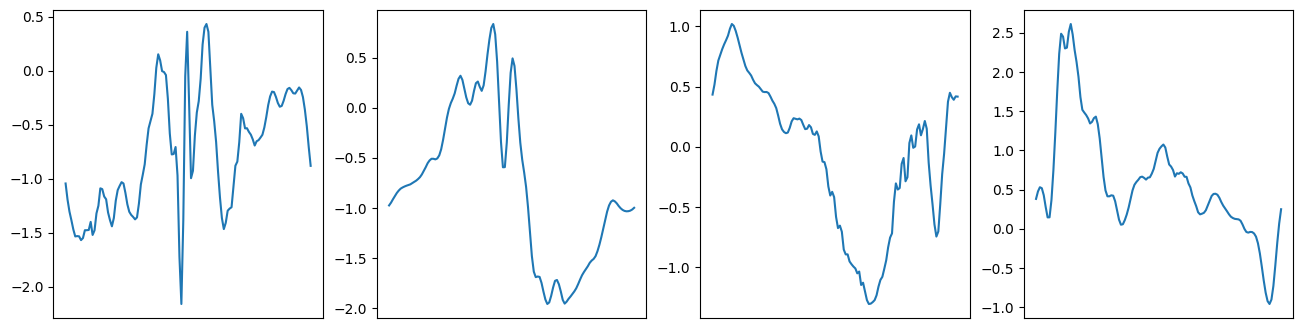

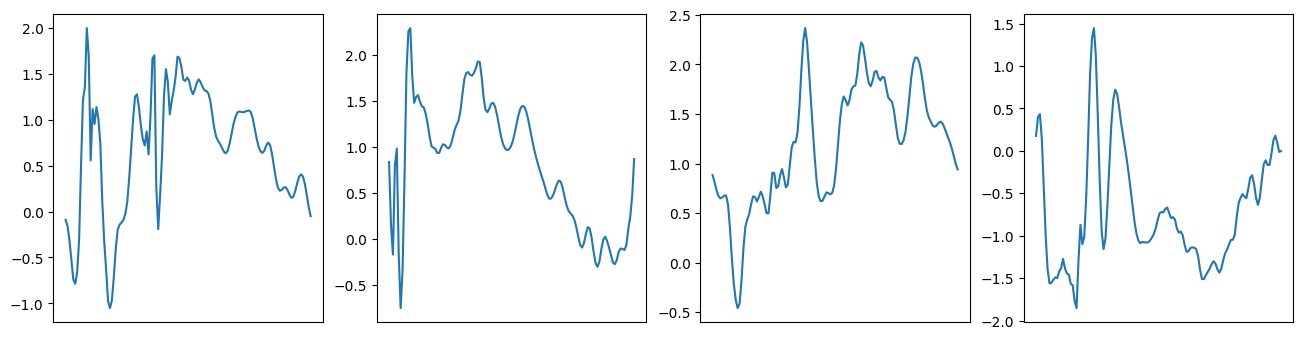

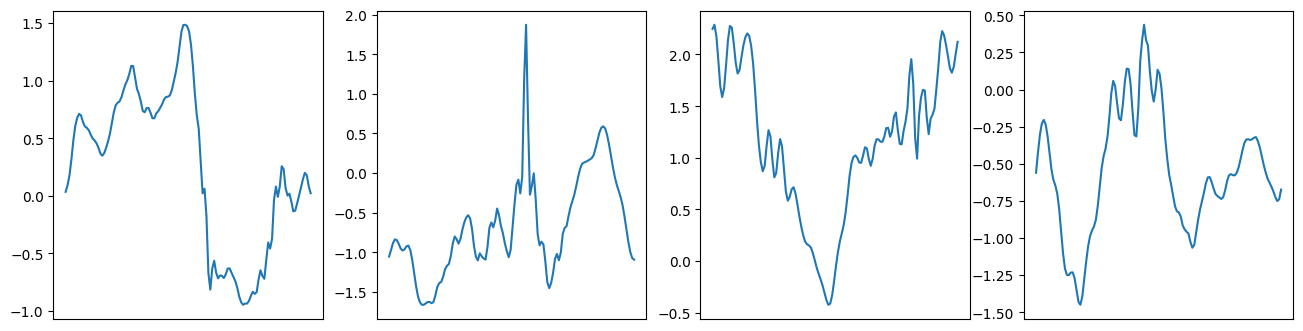

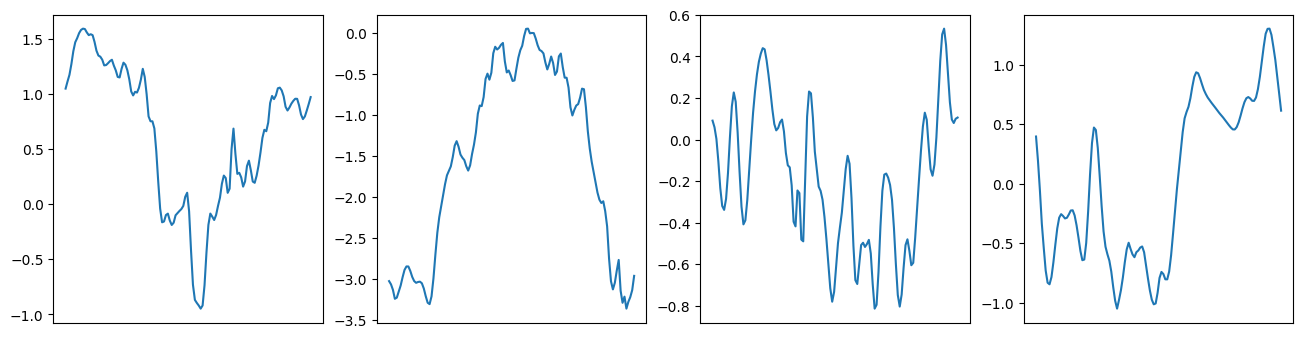

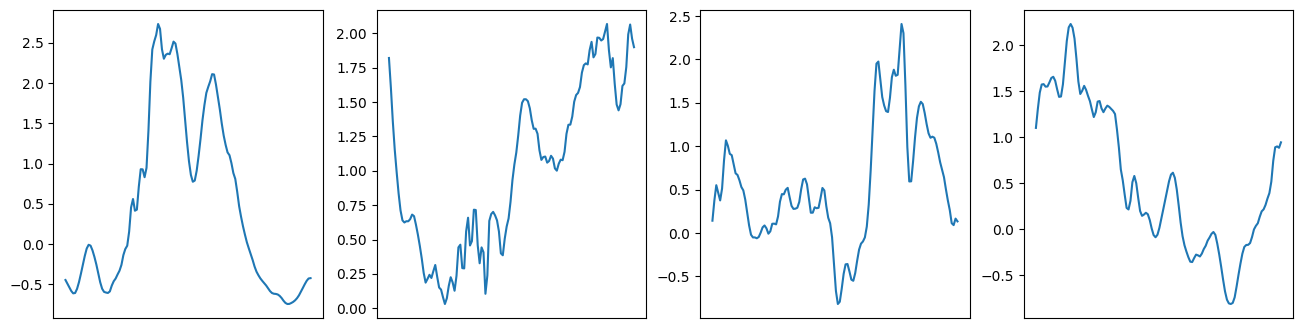

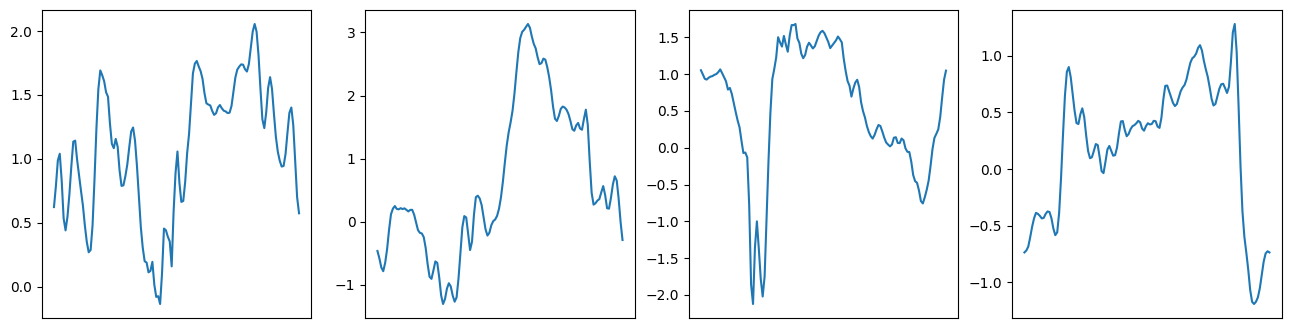

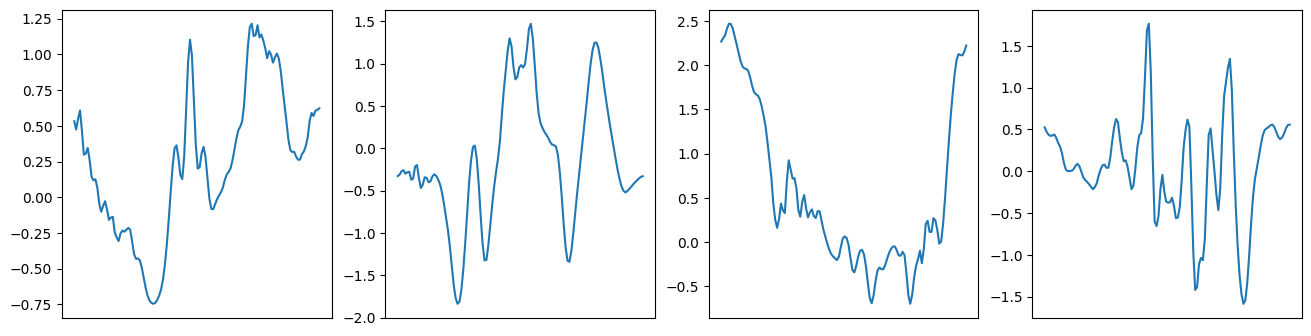

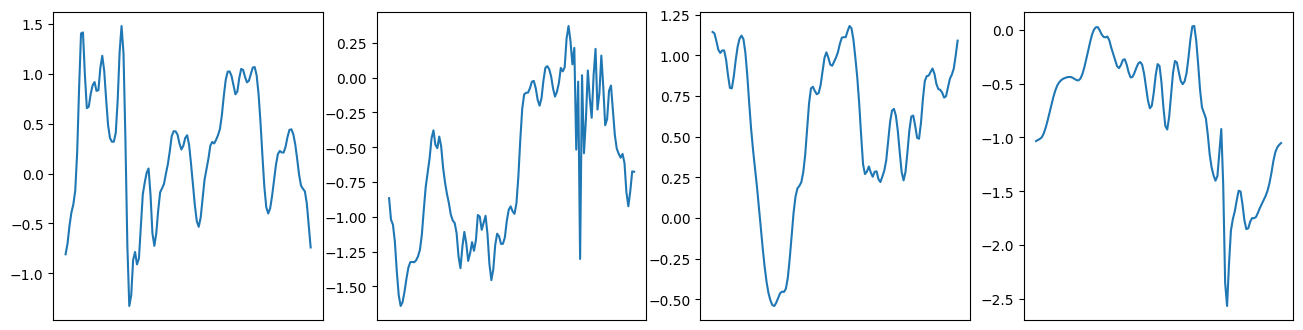

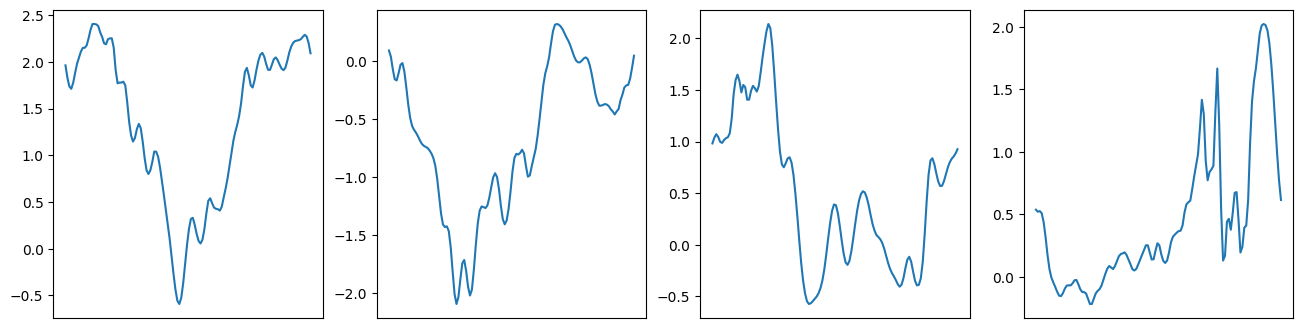

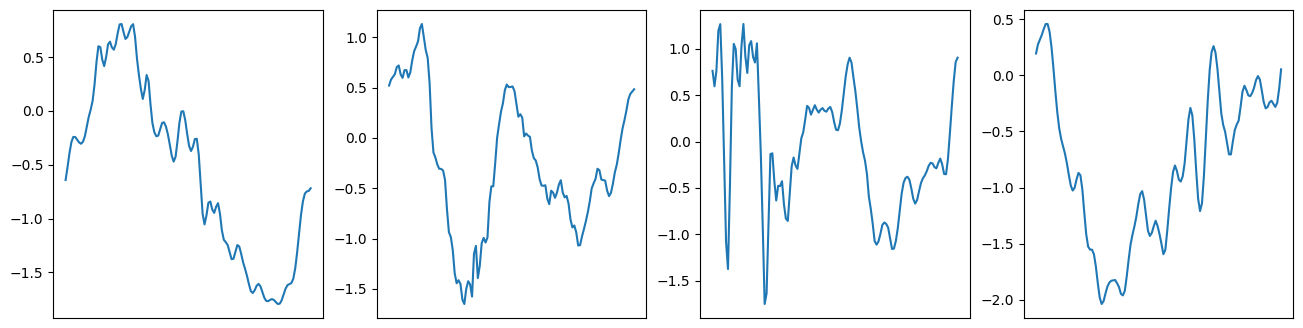

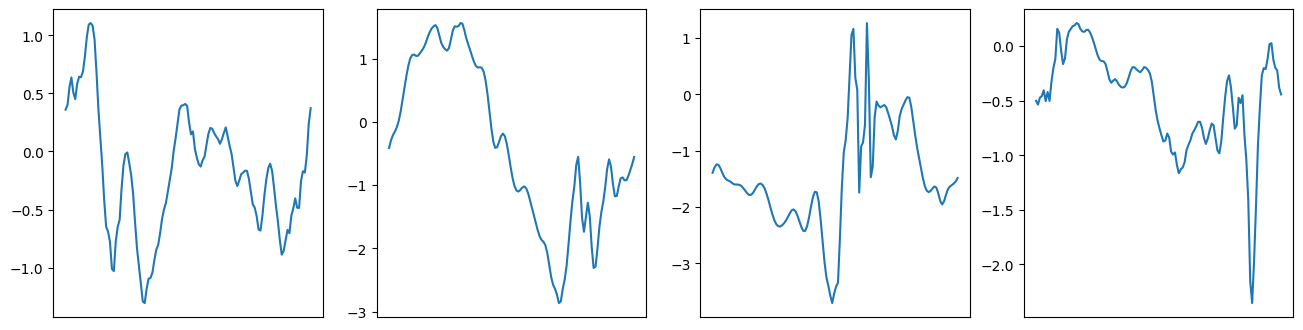

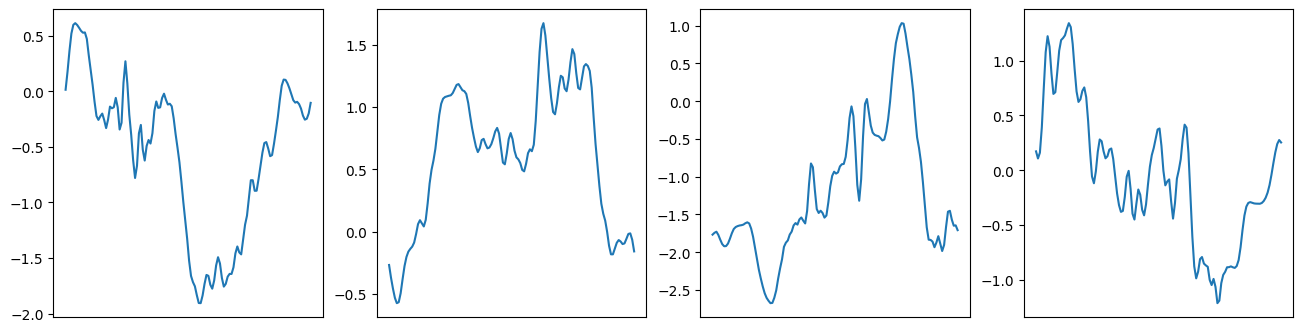

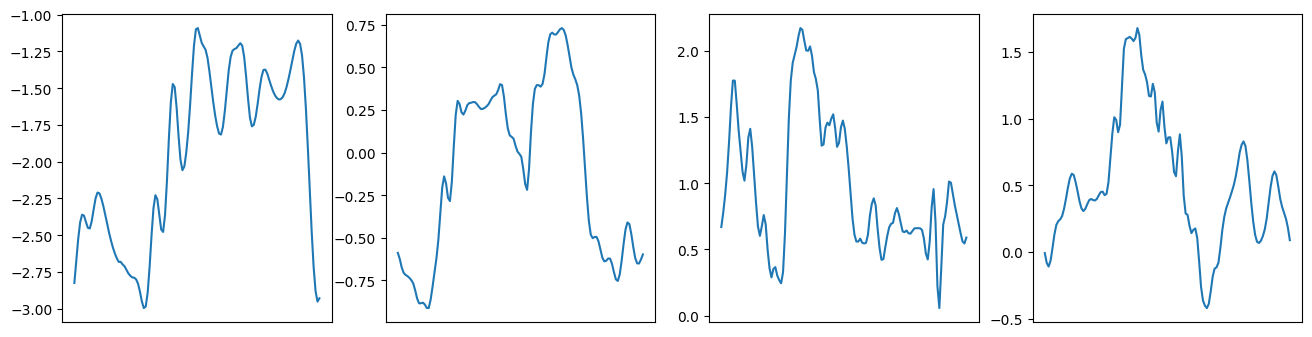

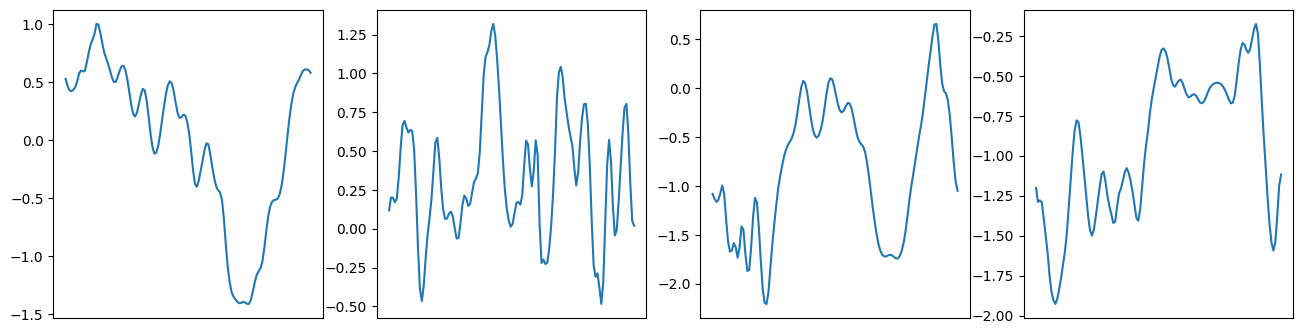

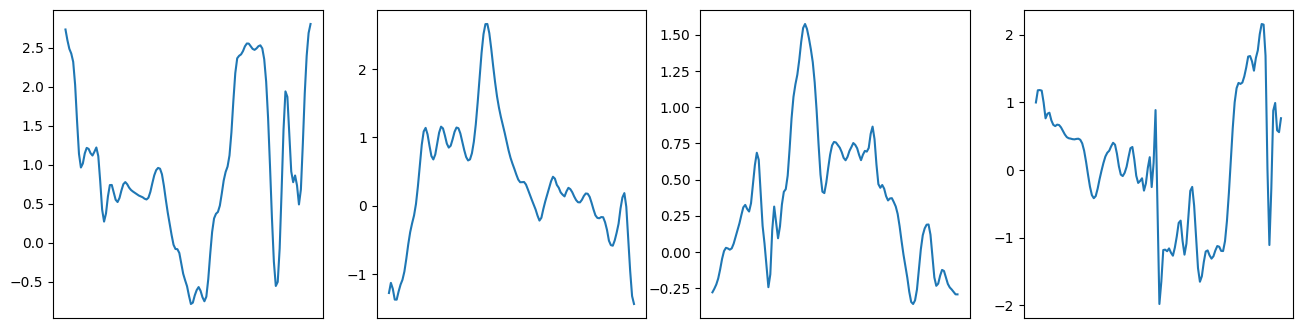

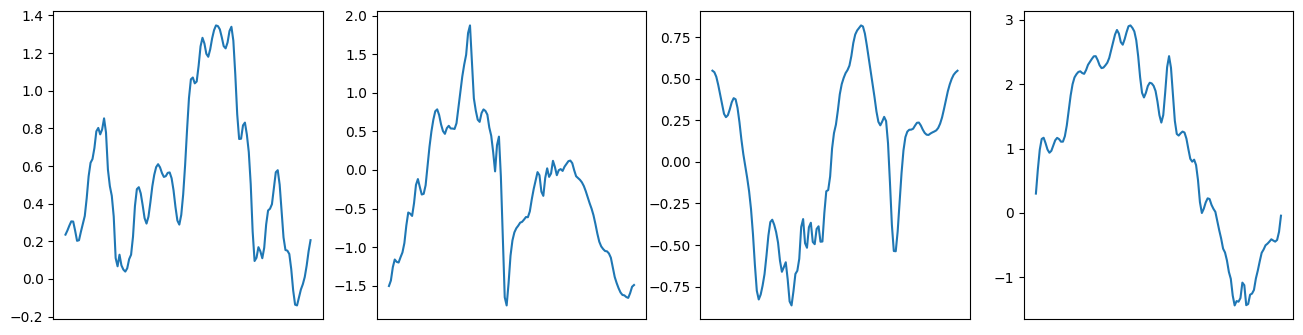

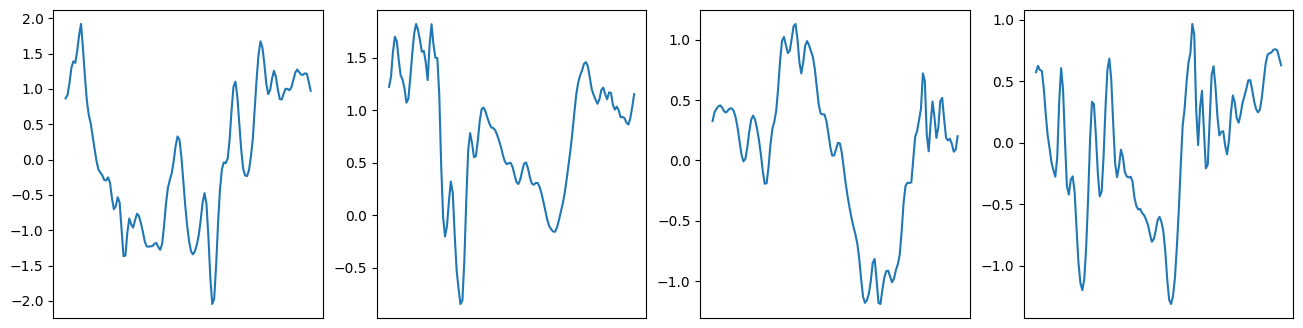

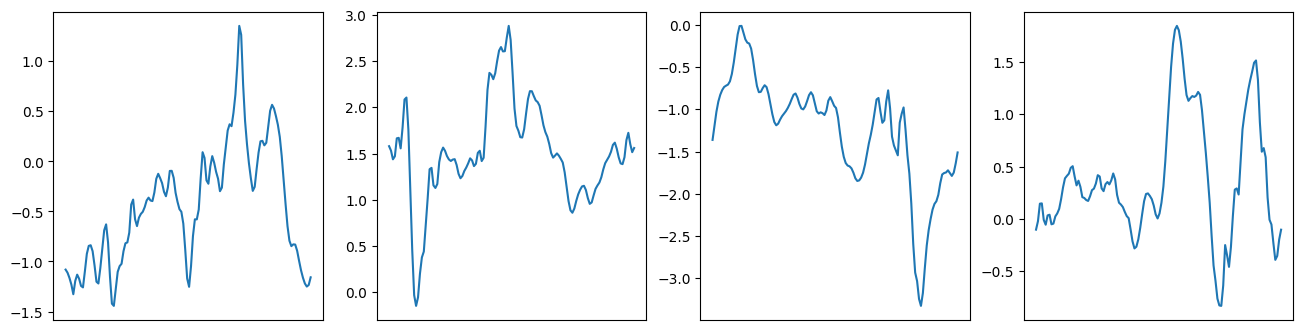

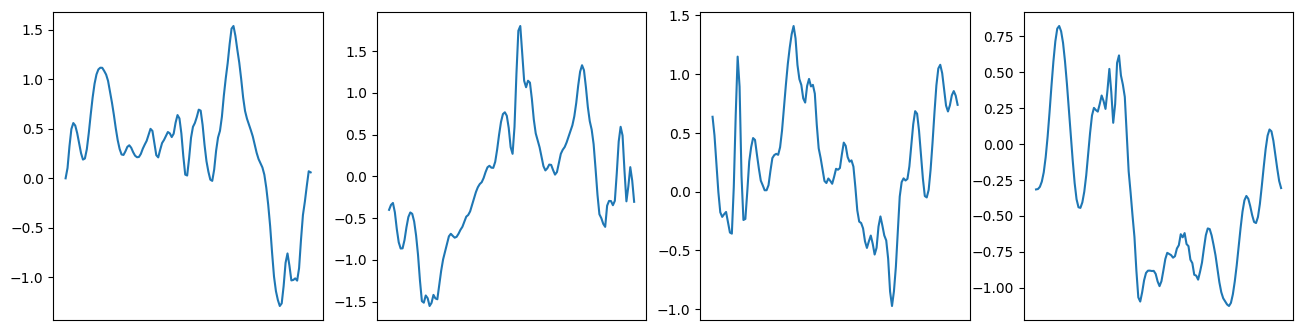

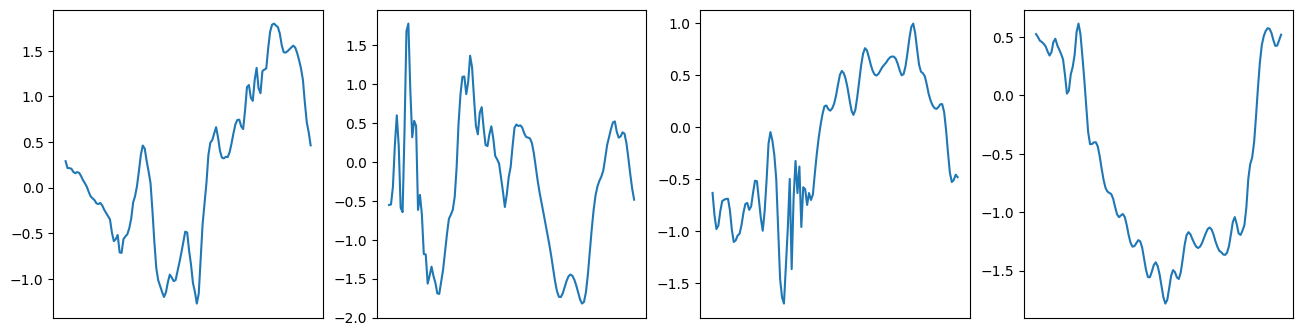

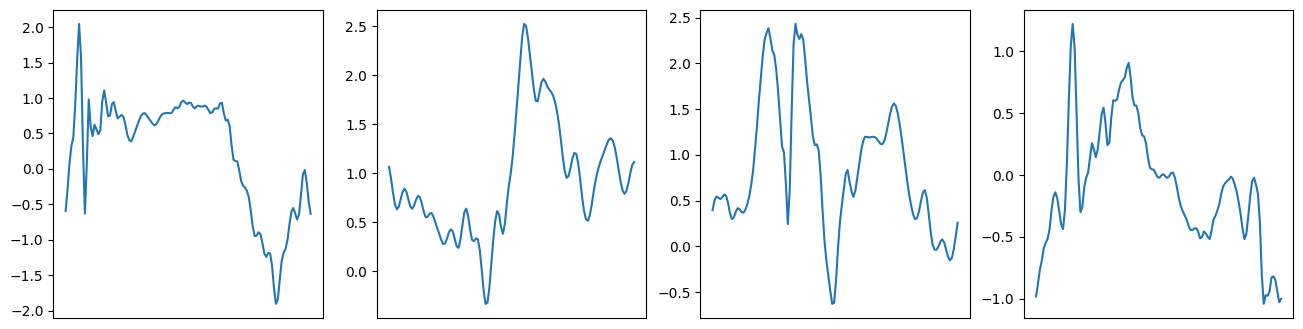

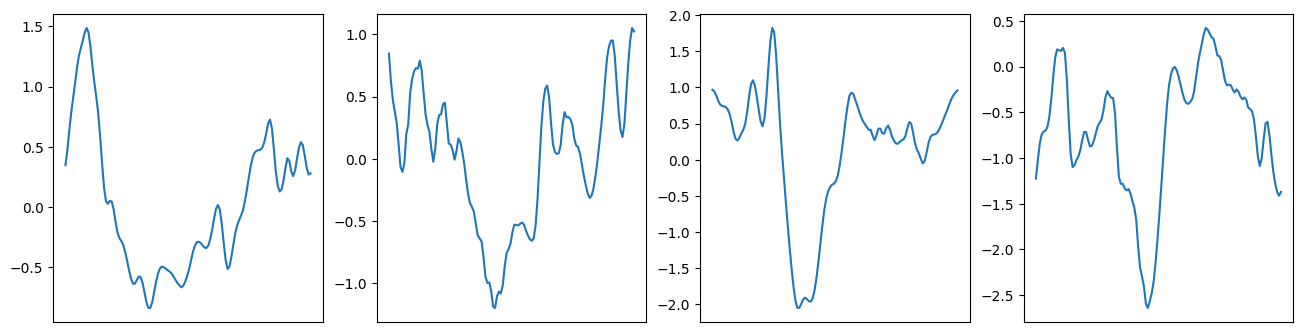

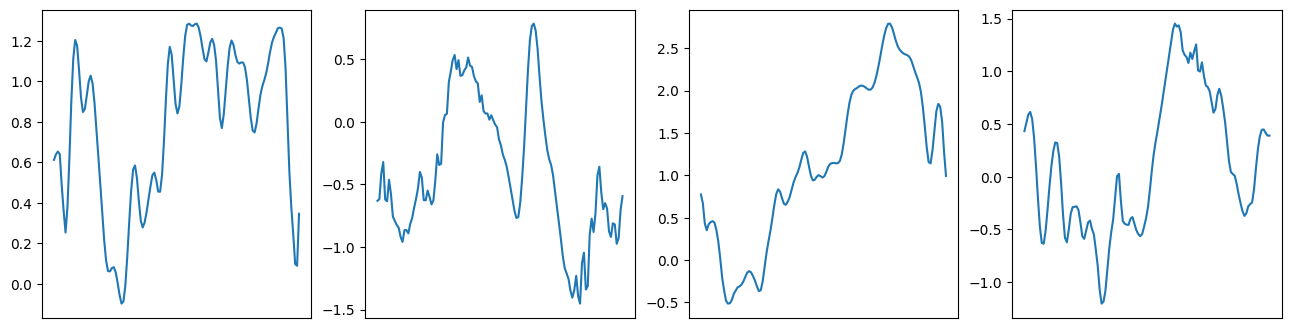

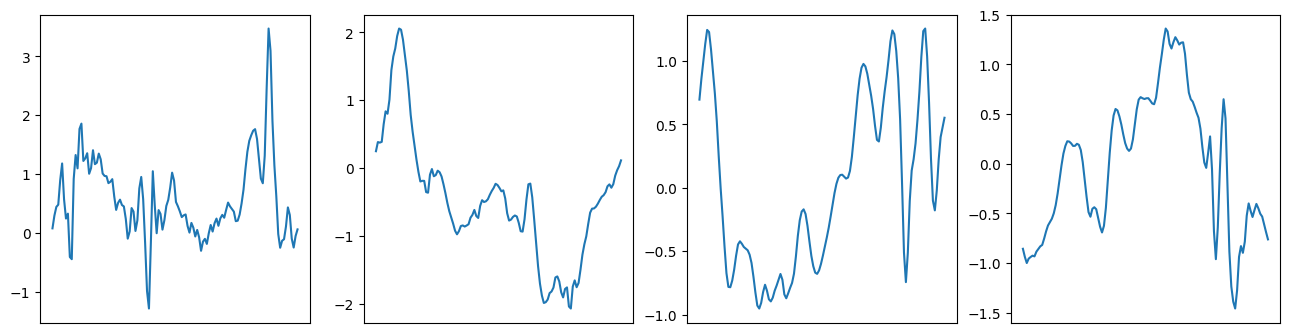

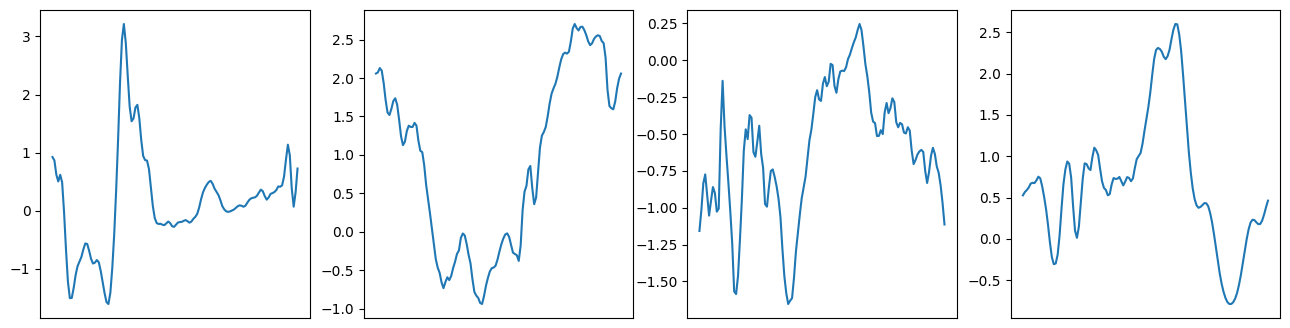

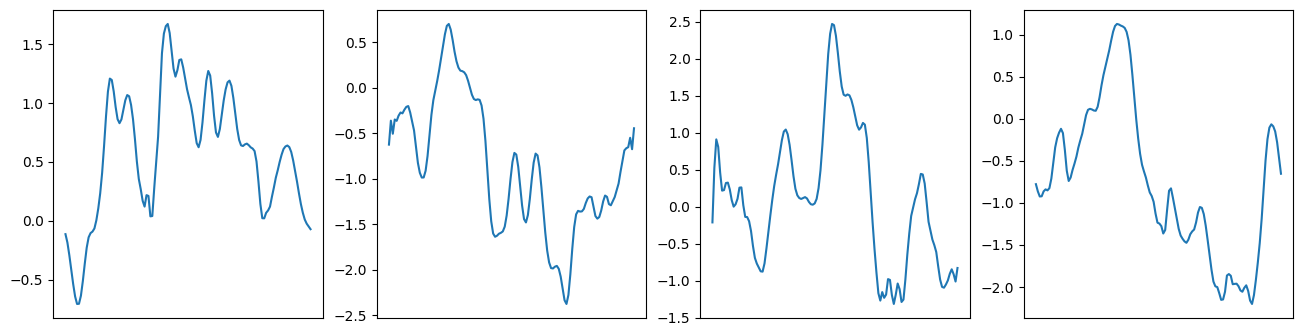

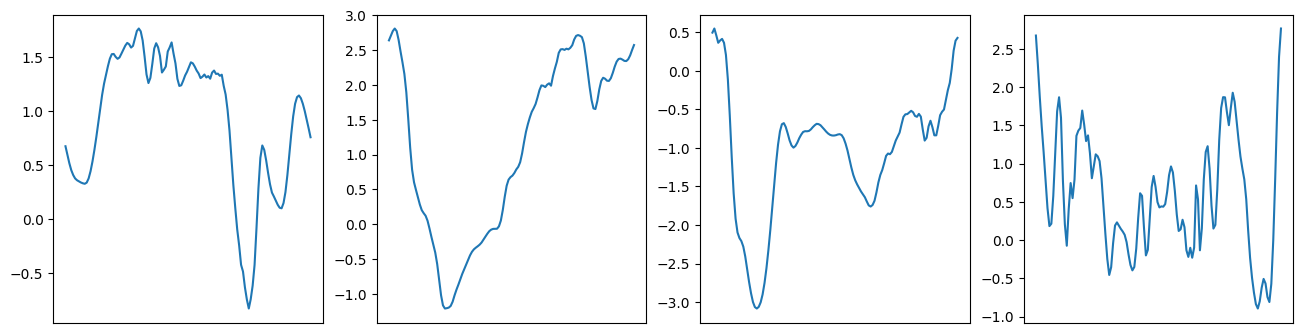

In [16]:
#Synthesis
for i in range(100):
    plot_time_series_row(xt[i*4:(i+1)*4], 4)
   


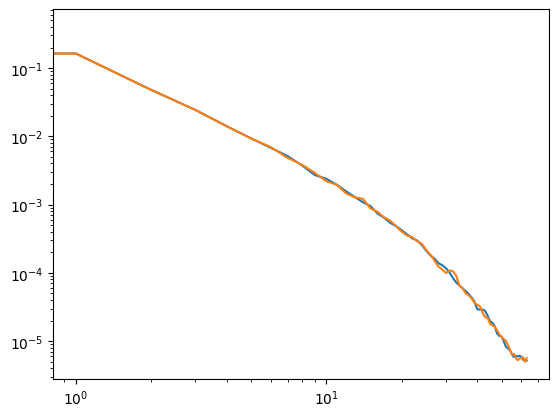

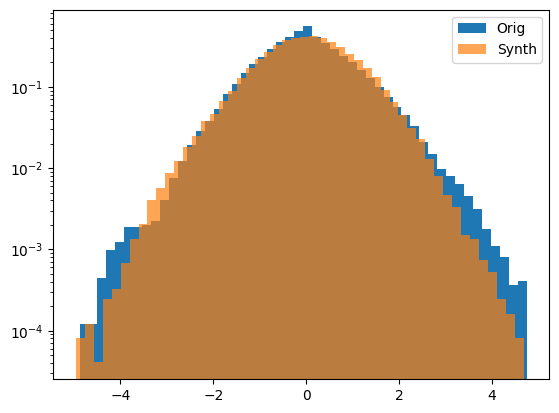

In [17]:
# Check Statistical Properties
spec_plot(x1,xt)

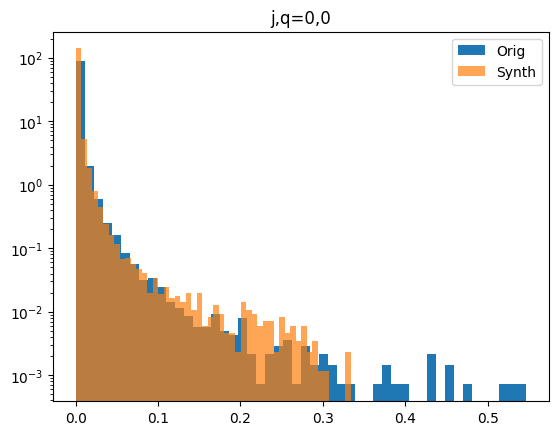

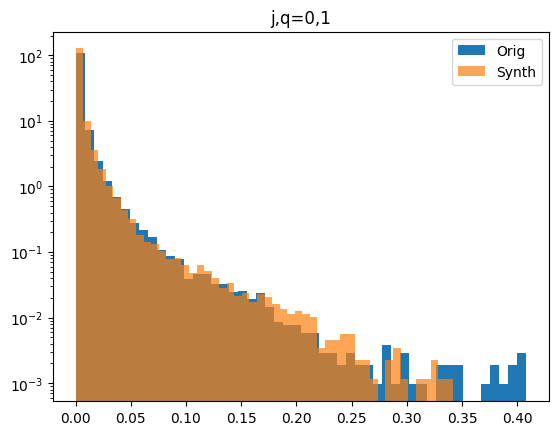

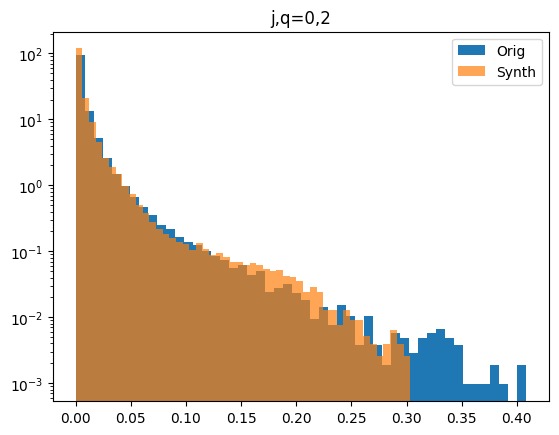

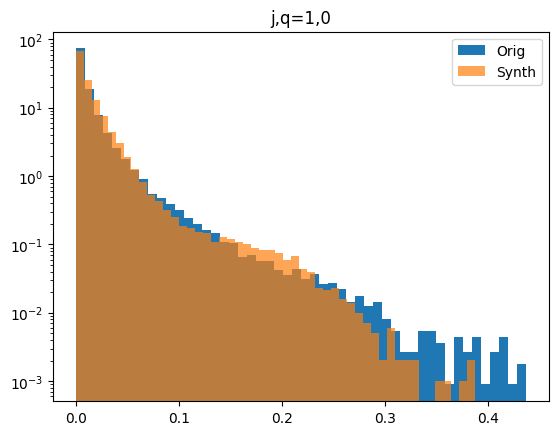

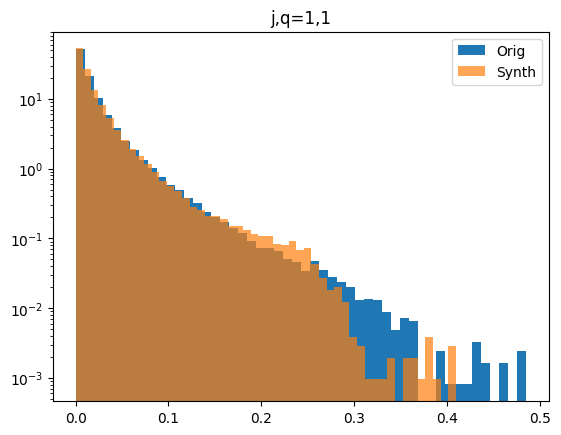

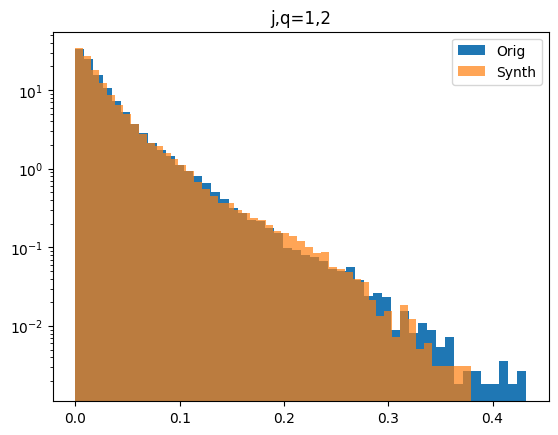

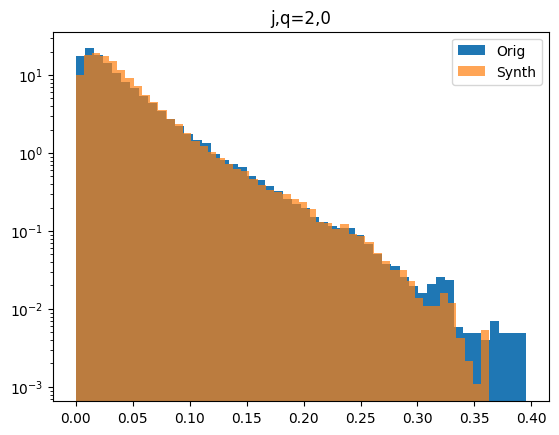

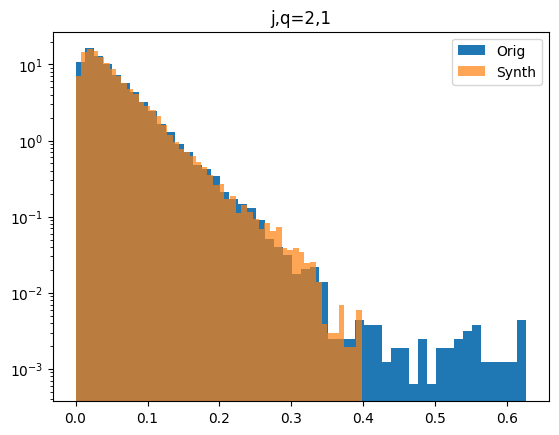

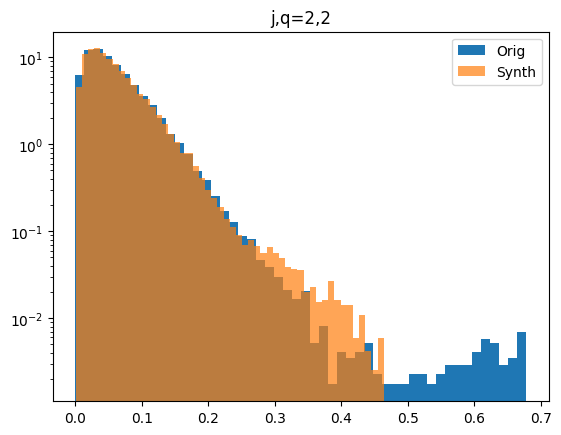

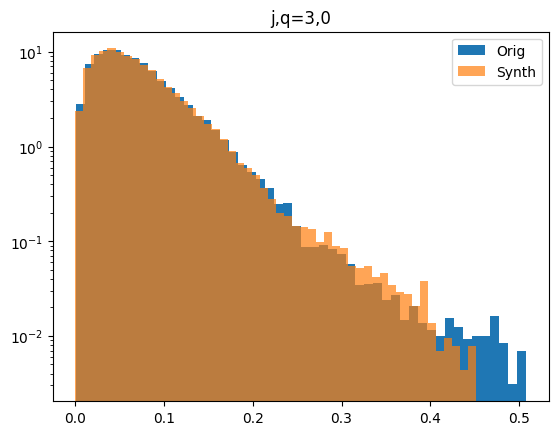

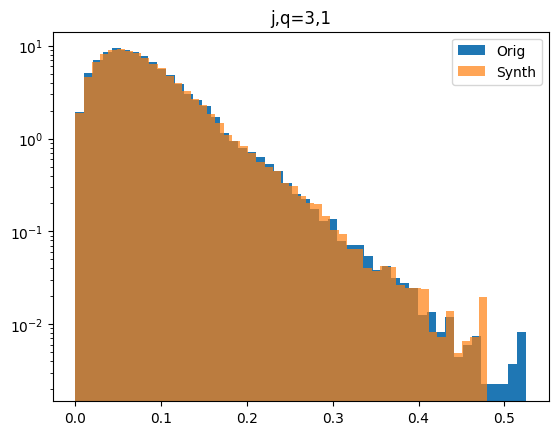

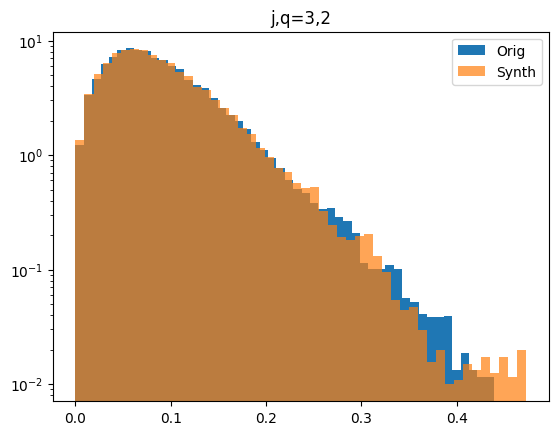

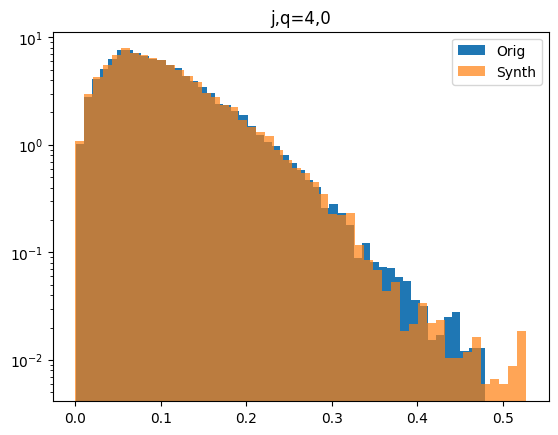

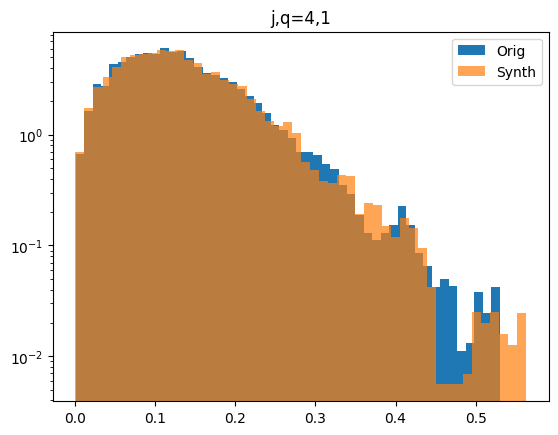

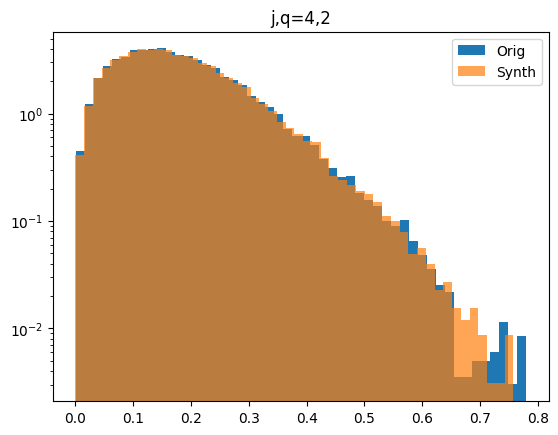

In [18]:
hist_plot(x1,xt)

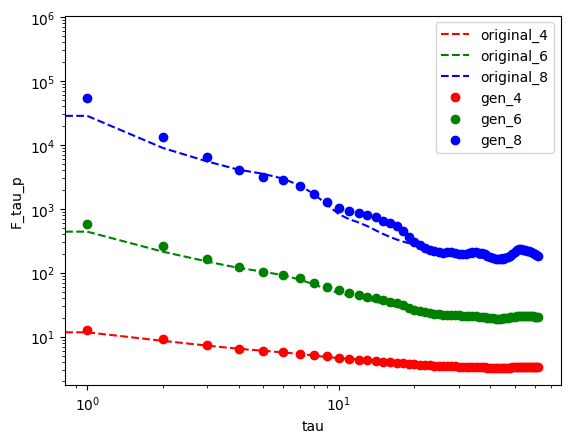

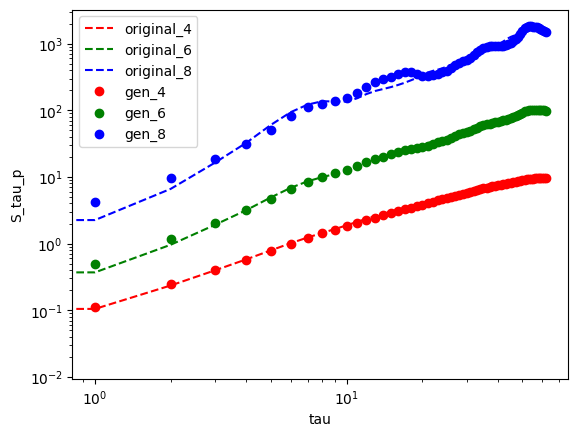

In [20]:
structure_plot(x1,xt)

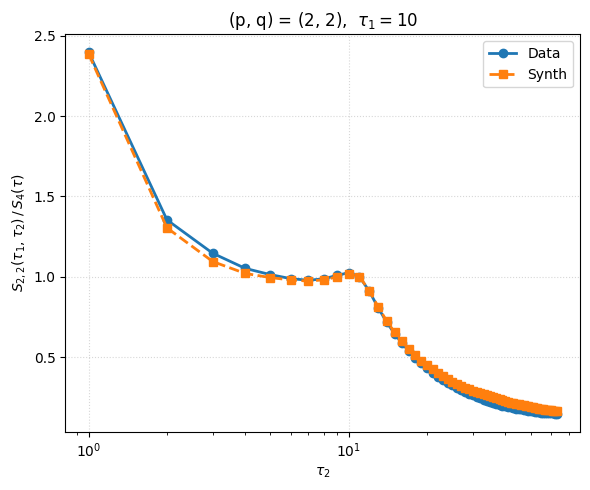

In [21]:
cross_plot_1d_normalized(x1, xt, fixed_tau=10, fix_axis=0)

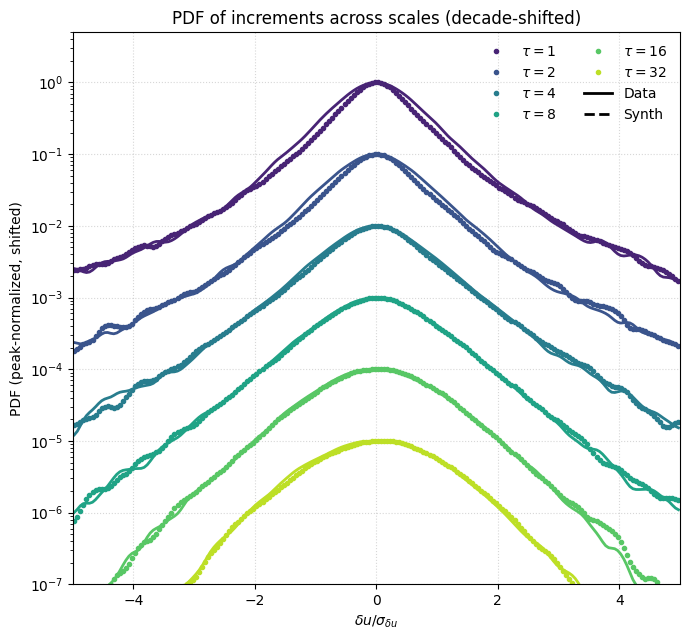

In [22]:
increment_pdf_plot(x1, xt,
                   taus=(1, 2, 4, 8, 16, 32),
                   xlim=(-5,5),
                   ylim=None, 
                   smooth=True, 
                   smooth_sigma=2.0)

(p,q)= (2, 2)


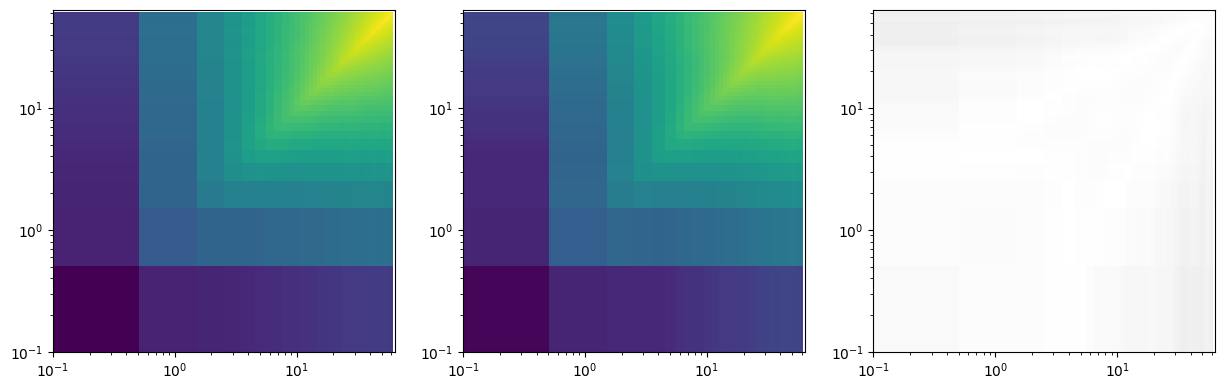

In [23]:
cross_plot(x1,xt,pq = [(2,2)])

(p,q)= (3, 1)


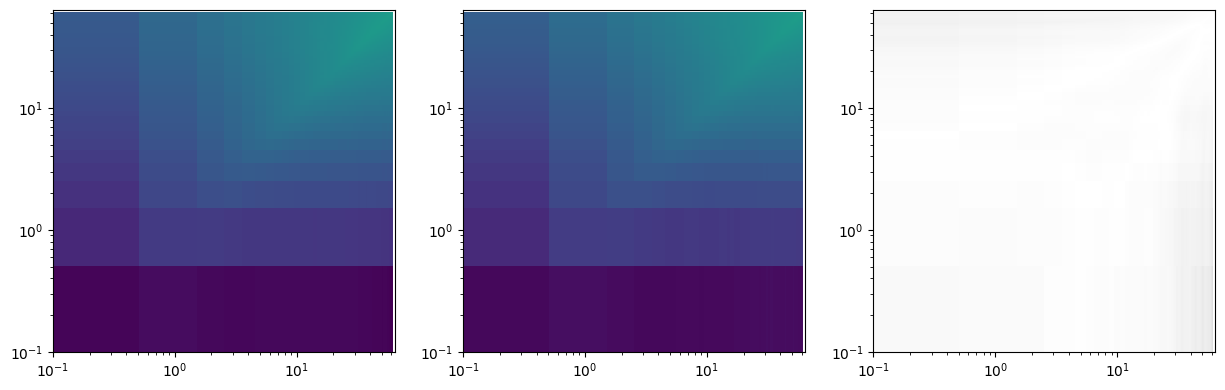

(p,q)= (3, 3)


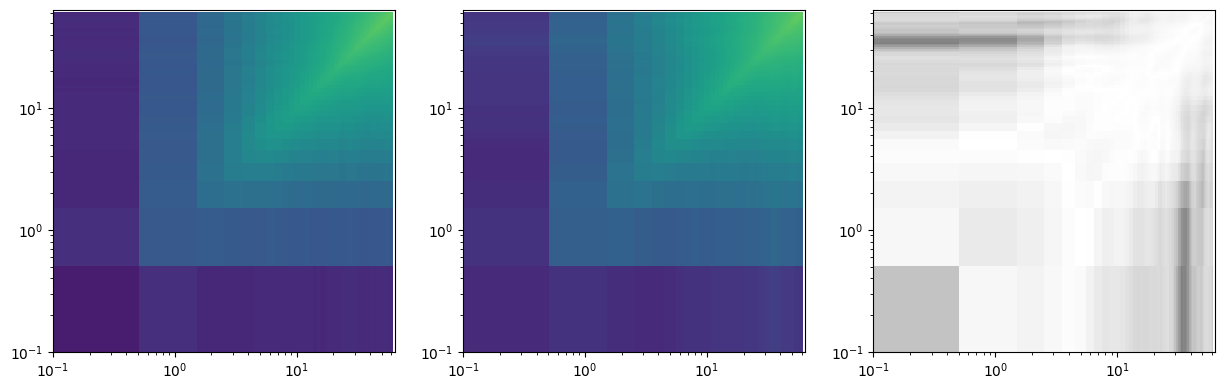

(p,q)= (4, 4)


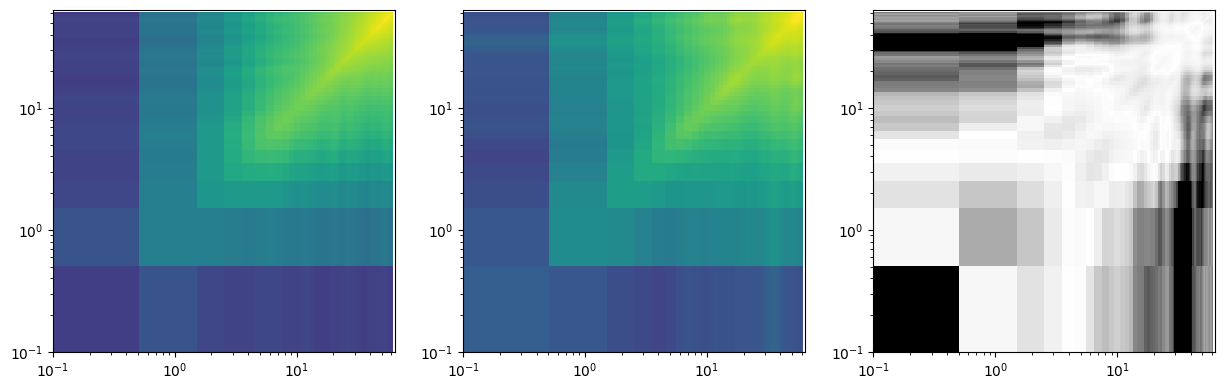

In [24]:
cross_plot(x1,xt,pq = [(3,1),(3,3),(4,4)])

Entropy bound evolution and comparison with the equivalent gaussian entropy (covariance directly estimated from the original data):

Entropy bound: tensor(nan) .


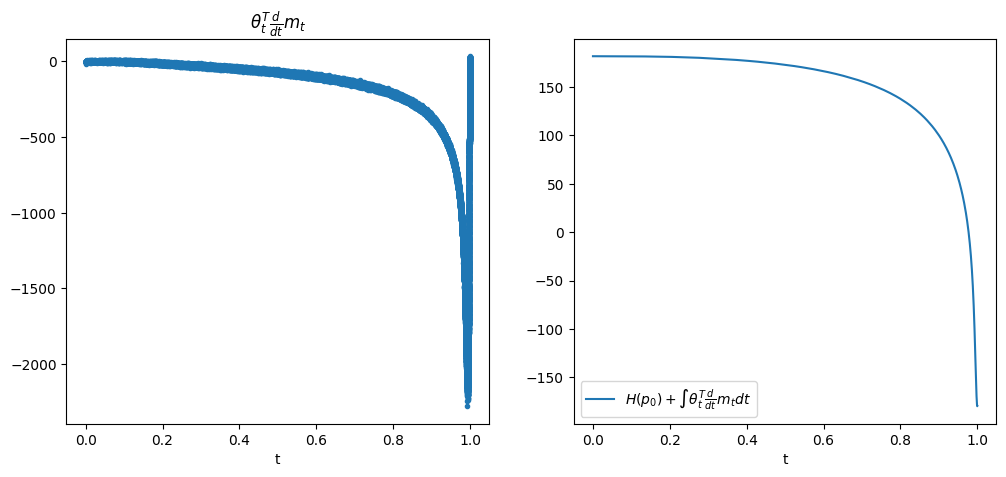

In [25]:
d = x1.shape[-2]*x1.shape[-1]
H_p_0 = (np.log(2*np.pi)+1)*d/2

H_t_bound = dH_t_bound.cumsum(0).cpu()/nt + H_p_0
print('Entropy bound:', H_t_bound[-1], '.')

plot_entropy_bound_evolution(dH_t_bound, H_t_bound, None, t)